# Train and save the single-coil MRI score prior on a 2000-level DSM time grid

This notebook trains/fine-tunes and saves the unconditional score prior using the same
forward noising dynamics as the SMC/DPS notebooks,

\[
    x_t=(1-t)x_0+\sqrt{t(2-t)}\,\epsilon,
\]

but samples the forward time from an explicit grid of 2,000 levels.  It additionally:

- uses configurable synthetic train/validation set sizes, with 3,000 as the default;
- evaluates 3,000 generated terminal-prior samples against 3,000 held-out images;
- saves an always-available DCT-feature Fr'echet distance and KID-style metric;
- optionally saves an Inception-v3 feature Fr'echet distance when pretrained weights are available;
- computes and saves terminal-tail statistics with `N_REF_TAIL=3000` by default;
- reuses the terminal reference samples generated for the tail calculation when computing prior-quality metrics, avoiding a second expensive prior-sampling pass.

`NUM_TRAIN_STEPS` remains the optimizer-update count.  The value 3,000 in the quality/tail
settings is a Monte Carlo sample count, not the number of diffusion time levels or optimizer steps.


## 0. Environment notes

Use the same Tuolumne/ROCm PyTorch environment as the SMC/DPS notebooks.

Recommended new-from-scratch run:

```bash
export DATA_MODE=fastmri_h5
export FASTMRI_TRAIN_ROOT=/path/to/knee_singlecoil_train
export FASTMRI_VAL_ROOT=/path/to/knee_singlecoil_val

export DSM_TIME_SAMPLING_MODE=discrete
export DSM_NUM_TIME_LEVELS=2000
export DSM_T_MIN=0.001
export DSM_T_MAX=0.98

export NUM_TRAIN_STEPS=50000
export LOAD_PRETRAINED=0
export RESUME_FROM_OUTPUT=1
```

The notebook writes to a DSM-2000-specific checkpoint name by default so it does not overwrite the earlier continuous-time prior.


In [1]:

import os
import gc
import json
import math
import time
import pathlib
import random
from typing import List, Tuple, Optional, Dict, Any

# Set matplotlib backend before importing pyplot. In batch jobs with no display, use Agg.
import matplotlib
if os.environ.get("DISPLAY", "") == "" and os.environ.get("MPLBACKEND", "") == "":
    matplotlib.use("Agg")
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display, clear_output
    HAVE_IPYTHON_DISPLAY = True
except Exception:
    HAVE_IPYTHON_DISPLAY = False

try:
    import h5py
except Exception as e:
    h5py = None
    print("WARNING: h5py is not available; fastMRI HDF5 loading will fail unless synthetic fallback is enabled.")
    print("h5py import error:", repr(e))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

# -----------------------------
# Environment helpers
# -----------------------------
def env_bool(name: str, default: bool) -> bool:
    val = os.environ.get(name, None)
    if val is None:
        return bool(default)
    return str(val).strip().lower() in {"1", "true", "yes", "y", "on"}


def env_int(name: str, default: int) -> int:
    return int(os.environ.get(name, str(default)))


def env_float(name: str, default: float) -> float:
    return float(os.environ.get(name, str(default)))


def env_str(name: str, default: str) -> str:
    return os.environ.get(name, default)


def env_int_list(name: str, default):
    val = os.environ.get(name, None)
    if val is None or str(val).strip() == "":
        return list(default)
    return [int(x) for x in str(val).replace(";", ",").split(",") if x.strip()]


def clear_device_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

# -----------------------------
# Reproducibility and device
# -----------------------------
SEED = env_int("SEED", 2026)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_default_dtype(torch.float32)
NUM_CPU_THREADS = env_int("NUM_CPU_THREADS", min(8, os.cpu_count() or 1))
try:
    torch.set_num_threads(NUM_CPU_THREADS)
except Exception:
    pass

# PyTorch ROCm intentionally exposes AMD GPUs through the torch.cuda API.
DEVICE = torch.device(env_str("TORCH_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))
PIN_MEMORY = env_bool("PIN_MEMORY", False)  # False is safer on ROCm/shared HPC nodes.
DATALOADER_NUM_WORKERS = env_int("DATALOADER_NUM_WORKERS", 0)
SHOW_PLOTS = env_bool("SHOW_PLOTS", True)
SAVE_FIGURES = env_bool("SAVE_FIGURES", True)

OUTPUT_DIR = pathlib.Path(env_str("OUTPUT_DIR", "./mri_score_prior_dsm2000_outputs")).expanduser()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    # On ROCm this may still be routed through MIOpen/cudnn compatibility layers.
    torch.backends.cudnn.benchmark = env_bool("CUDNN_BENCHMARK", True)
except Exception:
    pass

# -----------------------------
# Dataset configuration
# -----------------------------
DATA_MODE = env_str("DATA_MODE", "fastmri_h5")   # "fastmri_h5" or "synthetic"
FASTMRI_TRAIN_ROOT = env_str("FASTMRI_TRAIN_ROOT", "./knee_singlecoil_train")
FASTMRI_VAL_ROOT = env_str("FASTMRI_VAL_ROOT", "./knee_singlecoil_val")
ALLOW_SYNTHETIC_FALLBACK = env_bool("ALLOW_SYNTHETIC_FALLBACK", True)
MAX_FASTMRI_FILES = env_int("MAX_FASTMRI_FILES", 12)
MAX_SLICES_PER_FILE = env_int("MAX_SLICES_PER_FILE", 24)
IMG_SIZE = env_int("IMG_SIZE", 64)
SYNTHETIC_TRAIN_SIZE = env_int("SYNTHETIC_TRAIN_SIZE", 3000)
SYNTHETIC_VAL_SIZE = env_int("SYNTHETIC_VAL_SIZE", 3000)

# -----------------------------
# Score-prior model/training configuration
# -----------------------------
BATCH_SIZE = env_int("BATCH_SIZE", 16)
NUM_TRAIN_STEPS = env_int("NUM_TRAIN_STEPS", 50000)   # optimizer updates; independent of DSM_NUM_TIME_LEVELS
LR = env_float("LR", 2e-4)
WEIGHT_DECAY = env_float("WEIGHT_DECAY", 1e-4)
GRAD_CLIP_NORM = env_float("GRAD_CLIP_NORM", 1.0)
BASE_CHANNELS = env_int("BASE_CHANNELS", 32)
TIME_EMB_DIM = env_int("TIME_EMB_DIM", 128)

# Same DSM forward-noising dynamics as the SMC/DPS notebooks.
DSM_T_MIN = env_float("DSM_T_MIN", 1e-3)
DSM_T_MAX = env_float("DSM_T_MAX", 0.98)
DSM_WEIGHT_BY_SIGMA2 = env_bool("DSM_WEIGHT_BY_SIGMA2", True)

# Time sampling for DSM training.
#   "discrete": sample one of DSM_NUM_TIME_LEVELS equally spaced values.
#   "continuous": retain the original uniform continuous-time sampling.
#
# The default 2000-level grid preserves
#     x_t = (1-t)x_0 + sqrt(t*(2-t)) eps
# and is therefore compatible with the existing SMC/DPS prior equations.
DSM_TIME_SAMPLING_MODE = env_str("DSM_TIME_SAMPLING_MODE", "discrete").strip().lower()
DSM_NUM_TIME_LEVELS = env_int("DSM_NUM_TIME_LEVELS", 2000)
SAVE_DSM_TIME_GRID = env_bool("SAVE_DSM_TIME_GRID", True)

if DSM_TIME_SAMPLING_MODE not in {"continuous", "discrete"}:
    raise ValueError(
        "DSM_TIME_SAMPLING_MODE must be 'continuous' or 'discrete', "
        f"got {DSM_TIME_SAMPLING_MODE!r}"
    )
if DSM_NUM_TIME_LEVELS < 2:
    raise ValueError(f"DSM_NUM_TIME_LEVELS must be at least 2, got {DSM_NUM_TIME_LEVELS}")
if not (0.0 <= DSM_T_MIN < DSM_T_MAX <= 1.0):
    raise ValueError(
        "Expected 0 <= DSM_T_MIN < DSM_T_MAX <= 1, got "
        f"DSM_T_MIN={DSM_T_MIN}, DSM_T_MAX={DSM_T_MAX}"
    )

# Checkpoint policy.
# PRETRAINED_CHECKPOINT_PATH is loaded first when RESUME_FROM_OUTPUT=False or no output checkpoint exists.
# OUTPUT_CHECKPOINT_PATH is where this notebook saves the trained/fine-tuned model.
PRETRAINED_CHECKPOINT_PATH = pathlib.Path(
    env_str("PRETRAINED_CHECKPOINT_PATH", str(OUTPUT_DIR / f"score_prior_singlecoil_mri_{IMG_SIZE}.pt"))
).expanduser()
OUTPUT_CHECKPOINT_PATH = pathlib.Path(
    env_str("OUTPUT_CHECKPOINT_PATH", str(OUTPUT_DIR / f"score_prior_singlecoil_mri_{IMG_SIZE}_dsm2000_trained.pt"))
).expanduser()
LOAD_PRETRAINED = env_bool("LOAD_PRETRAINED", False)  # set True only for an intentional warm start
RESUME_FROM_OUTPUT = env_bool("RESUME_FROM_OUTPUT", True)
SAVE_CHECKPOINT = env_bool("SAVE_CHECKPOINT", True)
SAVE_EVERY = env_int("SAVE_EVERY", 1000)
SAVE_INTERMEDIATE_COPIES = env_bool("SAVE_INTERMEDIATE_COPIES", False)
KEEP_LOADED_LOSS_HISTORY = env_bool("KEEP_LOADED_LOSS_HISTORY", True)
STRICT_CHECKPOINT_LOAD = env_bool("STRICT_CHECKPOINT_LOAD", True)

# Loss plotting and diagnostics.
PLOT_SCORE_TRAINING_LOSS = env_bool("PLOT_SCORE_TRAINING_LOSS", True)
PLOT_DURING_TRAINING = env_bool("PLOT_DURING_TRAINING", True)
PLOT_EVERY = env_int("PLOT_EVERY", 200)
TRAIN_LOSS_SMOOTH_WINDOW = env_int("TRAIN_LOSS_SMOOTH_WINDOW", 100)
TRAIN_LOSS_TIME_BINS = env_int("TRAIN_LOSS_TIME_BINS", 16)
TRAIN_LOSS_EVAL_BATCHES = env_int("TRAIN_LOSS_EVAL_BATCHES", 2)

# -----------------------------
# Same terminal multiscale time dynamics as the uploaded notebooks
# -----------------------------
# These are not training iterations. They control optional prior preview sampling after training.
# Each level integrates over the full terminal interval [T0,T1] and evaluates at terminal time T1.
SAMPLER_TYPE = env_str("SAMPLER_TYPE", "sde")
REVERSE_T_START = env_float("REVERSE_T_START", 0.03)
T0 = env_float("T0", REVERSE_T_START)
T1 = env_float("T1", 1.0)
BASE_NOISE_MODE = env_str("BASE_NOISE_MODE", "notebook_constant")  # "notebook_constant" or "sqrt_2_over_t"
SAMPLE_CLAMP = None if env_str("SAMPLE_CLAMP", "4.0").lower() == "none" else env_float("SAMPLE_CLAMP", 4.0)
NUM_REF_LEVELS = env_int("NUM_REF_LEVELS", 10)
N_STEPS_REF_BY_LEVEL = env_int_list("STEPS_BY_LEVEL", [100, 120, 140, 160, 180, 200, 220, 240])
if len(N_STEPS_REF_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_REF_BY_LEVEL)}")
N_STEPS_BASELINE_BY_LEVEL = env_int_list("BASELINE_STEPS_BY_LEVEL", N_STEPS_REF_BY_LEVEL)
if len(N_STEPS_BASELINE_BY_LEVEL) != NUM_REF_LEVELS:
    raise ValueError(f"BASELINE_STEPS_BY_LEVEL must have length NUM_REF_LEVELS={NUM_REF_LEVELS}, got {len(N_STEPS_BASELINE_BY_LEVEL)}")
SAMPLE_CHUNK_SIZE = env_int("SAMPLE_CHUNK_SIZE", 64)
RUN_PRIOR_PREVIEW = env_bool("RUN_PRIOR_PREVIEW", False)
PRIOR_PREVIEW_BATCH_SIZE = env_int("PRIOR_PREVIEW_BATCH_SIZE", min(8, BATCH_SIZE))

# Prior-sample quality evaluation.
# Generated samples are terminal reference-level samples S_{NUM_REF_LEVELS-1}(T1).
RUN_PRIOR_QUALITY_METRICS = env_bool("RUN_PRIOR_QUALITY_METRICS", True)
PRIOR_QUALITY_NUM_GENERATED = env_int("PRIOR_QUALITY_NUM_GENERATED", 3000)
PRIOR_QUALITY_NUM_REAL = env_int("PRIOR_QUALITY_NUM_REAL", 3000)
PRIOR_QUALITY_SAMPLE_CHUNK_SIZE = env_int("PRIOR_QUALITY_SAMPLE_CHUNK_SIZE", SAMPLE_CHUNK_SIZE)
PRIOR_QUALITY_FEATURE_BATCH_SIZE = env_int("PRIOR_QUALITY_FEATURE_BATCH_SIZE", 64)
# auto: use cached Inception-v3 weights when available, and always compute DCT metrics.
# inception: require Inception-v3 features (unless the load fails, in which case the failure is recorded).
# dct: compute only the domain-specific DCT feature metrics.
PRIOR_QUALITY_FEATURE_BACKEND = env_str("PRIOR_QUALITY_FEATURE_BACKEND", "auto").strip().lower()
PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD = env_bool("PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD", False)
PRIOR_QUALITY_DCT_SIZE = env_int("PRIOR_QUALITY_DCT_SIZE", 16)
PRIOR_QUALITY_KID_SUBSETS = env_int("PRIOR_QUALITY_KID_SUBSETS", 20)
PRIOR_QUALITY_KID_SUBSET_SIZE = env_int("PRIOR_QUALITY_KID_SUBSET_SIZE", 500)
PRIOR_QUALITY_DIVERSITY_PAIRS = env_int("PRIOR_QUALITY_DIVERSITY_PAIRS", 5000)
PRIOR_QUALITY_SAVE_SAMPLE_TENSORS = env_bool("PRIOR_QUALITY_SAVE_SAMPLE_TENSORS", False)
PRIOR_QUALITY_GRID_COUNT = env_int("PRIOR_QUALITY_GRID_COUNT", 12)

if PRIOR_QUALITY_FEATURE_BACKEND not in {"auto", "inception", "dct"}:
    raise ValueError(
        "PRIOR_QUALITY_FEATURE_BACKEND must be 'auto', 'inception', or 'dct', "
        f"got {PRIOR_QUALITY_FEATURE_BACKEND!r}"
    )
if PRIOR_QUALITY_NUM_GENERATED <= 1 or PRIOR_QUALITY_NUM_REAL <= 1:
    raise ValueError("Prior quality metrics require at least two generated and two real samples.")
if PRIOR_QUALITY_DCT_SIZE < 1 or PRIOR_QUALITY_DCT_SIZE > IMG_SIZE:
    raise ValueError(
        f"PRIOR_QUALITY_DCT_SIZE must be in [1,{IMG_SIZE}], got {PRIOR_QUALITY_DCT_SIZE}"
    )

# Optional terminal-tail diagnostics after training.
# These statistics check how much unresolved terminal mass remains when S_m is compared with S_ref.
RUN_TAIL_STATS = env_bool("RUN_TAIL_STATS", True)
N_REF_TAIL = env_int("N_REF_TAIL", 3000)   # paper-scale Monte Carlo tail estimate
NUM_TAIL_LEVELS = env_int("NUM_TAIL_LEVELS", min(8, NUM_REF_LEVELS))
if NUM_TAIL_LEVELS < 1 or NUM_TAIL_LEVELS > NUM_REF_LEVELS:
    raise ValueError(f"NUM_TAIL_LEVELS must be in [1, NUM_REF_LEVELS={NUM_REF_LEVELS}], got {NUM_TAIL_LEVELS}")
TAIL_STATS_CHUNK_SIZE = env_int("TAIL_STATS_CHUNK_SIZE", SAMPLE_CHUNK_SIZE)
USE_MONOTONE_GAP = env_bool("USE_MONOTONE_GAP", True)

print("Torch version:", torch.__version__)
print("Torch HIP/ROCm version:", getattr(torch.version, "hip", None))
print("CUDA API available (ROCm uses this name too):", torch.cuda.is_available())
print("Device:", DEVICE)
print("CPU threads:", NUM_CPU_THREADS)
print("ROCR_VISIBLE_DEVICES:", os.environ.get("ROCR_VISIBLE_DEVICES"))
print("HIP_VISIBLE_DEVICES:", os.environ.get("HIP_VISIBLE_DEVICES"))
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU 0:", torch.cuda.get_device_name(0))

print("\nData:", DATA_MODE)
print("FASTMRI_TRAIN_ROOT:", FASTMRI_TRAIN_ROOT)
print("FASTMRI_VAL_ROOT:", FASTMRI_VAL_ROOT)
print("IMG_SIZE:", IMG_SIZE, "BATCH_SIZE:", BATCH_SIZE, "NUM_TRAIN_STEPS:", NUM_TRAIN_STEPS)
print("Synthetic train/validation sizes:", SYNTHETIC_TRAIN_SIZE, SYNTHETIC_VAL_SIZE)
print("DSM time range:", DSM_T_MIN, DSM_T_MAX, "sigma(t)=sqrt(t*(2-t))")
print("DSM time sampling mode:", DSM_TIME_SAMPLING_MODE)
print("DSM number of time levels:", DSM_NUM_TIME_LEVELS)
if DSM_TIME_SAMPLING_MODE == "discrete":
    print("DSM grid spacing:", (DSM_T_MAX - DSM_T_MIN) / float(DSM_NUM_TIME_LEVELS - 1))
print("Terminal prior time interval [T0,T1]:", T0, T1)
print("Reference terminal steps by level:", N_STEPS_REF_BY_LEVEL)
print("RUN_PRIOR_QUALITY_METRICS:", RUN_PRIOR_QUALITY_METRICS)
print("Prior quality generated/real counts:", PRIOR_QUALITY_NUM_GENERATED, PRIOR_QUALITY_NUM_REAL)
print("Prior quality feature backend:", PRIOR_QUALITY_FEATURE_BACKEND)
print("RUN_TAIL_STATS:", RUN_TAIL_STATS, "N_REF_TAIL:", N_REF_TAIL, "NUM_TAIL_LEVELS:", NUM_TAIL_LEVELS)
print("PRETRAINED_CHECKPOINT_PATH:", PRETRAINED_CHECKPOINT_PATH)
print("OUTPUT_CHECKPOINT_PATH:", OUTPUT_CHECKPOINT_PATH)


h5py import error: ImportError('libmpi.so.12: cannot open shared object file: No such file or directory')
Torch version: 2.8.0+cu128
Torch HIP/ROCm version: None
CUDA API available (ROCm uses this name too): False
Device: cpu
CPU threads: 8
ROCR_VISIBLE_DEVICES: 0,1,2,3
HIP_VISIBLE_DEVICES: None

Data: fastmri_h5
FASTMRI_TRAIN_ROOT: ./knee_singlecoil_train
FASTMRI_VAL_ROOT: ./knee_singlecoil_val
IMG_SIZE: 64 BATCH_SIZE: 16 NUM_TRAIN_STEPS: 50000
Synthetic train/validation sizes: 3000 3000
DSM time range: 0.001 0.98 sigma(t)=sqrt(t*(2-t))
DSM time sampling mode: discrete
DSM number of time levels: 2000
DSM grid spacing: 0.0004897448724362181
Terminal prior time interval [T0,T1]: 0.03 1.0
Reference terminal steps by level: [100, 120, 140, 160, 180, 200, 220, 240]
RUN_PRIOR_QUALITY_METRICS: True
Prior quality generated/real counts: 3000 3000
Prior quality feature backend: auto
RUN_TAIL_STATS: True N_REF_TAIL: 3000 NUM_TAIL_LEVELS: 5
PRETRAINED_CHECKPOINT_PATH: mri_score_prior_dsm2000_outp


## 1. Dataset utilities

The fastMRI loader matches the uploaded notebooks. If local fastMRI HDF5 files are unavailable and `ALLOW_SYNTHETIC_FALLBACK=True`, the notebook falls back to a synthetic phantom dataset for code/debugging runs.


In [2]:

def fft2c_img(x: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D FFT.

    x: real tensor (B,1,H,W) or (B,H,W)
    returns: complex tensor (B,H,W)
    """
    if x.ndim == 4:
        x = x[:, 0]
    x = torch.fft.ifftshift(x, dim=(-2, -1))
    k = torch.fft.fft2(x.to(torch.complex64), norm="ortho")
    k = torch.fft.fftshift(k, dim=(-2, -1))
    return k


def ifft2c_img(k: torch.Tensor) -> torch.Tensor:
    """Centered orthonormal 2D inverse FFT.

    k: complex tensor (B,H,W) or (H,W)
    returns: complex tensor with same leading batch convention
    """
    single = False
    if k.ndim == 2:
        k = k[None]
        single = True
    k = torch.fft.ifftshift(k, dim=(-2, -1))
    x = torch.fft.ifft2(k.to(torch.complex64), norm="ortho")
    x = torch.fft.fftshift(x, dim=(-2, -1))
    return x[0] if single else x


def center_crop_2d(x: torch.Tensor, crop_hw: Tuple[int, int]) -> torch.Tensor:
    h, w = x.shape[-2:]
    ch, cw = crop_hw
    ch = min(ch, h)
    cw = min(cw, w)
    top = (h - ch) // 2
    left = (w - cw) // 2
    return x[..., top:top + ch, left:left + cw]


def resize_2d(x: torch.Tensor, size: int) -> torch.Tensor:
    """Resize a single image tensor (H,W) to (size,size)."""
    x4 = x[None, None].float()
    y = F.interpolate(x4, size=(size, size), mode="bilinear", align_corners=False)
    return y[0, 0]


def robust_normalize_to_minus1_1(x: torch.Tensor, q_low=0.01, q_high=0.995) -> torch.Tensor:
    """Per-slice robust scaling to [-1,1]."""
    x = torch.nan_to_num(x.float(), nan=0.0, posinf=0.0, neginf=0.0)
    lo = torch.quantile(x.flatten(), q_low)
    hi = torch.quantile(x.flatten(), q_high)
    scale = torch.clamp(hi - lo, min=1e-6)
    x = (x - lo) / scale
    x = torch.clamp(x, 0.0, 1.0)
    return 2.0 * x - 1.0


def h5_complex_to_torch(arr: np.ndarray) -> torch.Tensor:
    """Convert common HDF5 complex formats to a complex torch tensor."""
    a = np.asarray(arr)
    if np.iscomplexobj(a):
        return torch.from_numpy(a.astype(np.complex64))
    # Some datasets store complex as last dimension [real, imag].
    if a.ndim >= 1 and a.shape[-1] == 2:
        t = torch.from_numpy(a.astype(np.float32))
        return torch.view_as_complex(t.contiguous())
    return torch.from_numpy(a.astype(np.float32)).to(torch.complex64)


class FastMRISingleCoilSliceDataset(Dataset):
    """Local fastMRI single-coil HDF5 slice dataset.

    Expected root: directory containing *.h5 files from knee_singlecoil_train or knee_singlecoil_val.
    """
    def __init__(self, root: str, img_size: int = 64, max_files: Optional[int] = None,
                 max_slices_per_file: Optional[int] = None):
        if h5py is None:
            raise RuntimeError("h5py is not available in this Python environment.")
        self.root = pathlib.Path(root)
        self.img_size = int(img_size)
        self.files = sorted(self.root.glob("*.h5"))
        if max_files is not None:
            self.files = self.files[:int(max_files)]
        self.index = []
        for fp in self.files:
            try:
                with h5py.File(fp, "r") as f:
                    if "reconstruction_esc" in f:
                        n_slices = f["reconstruction_esc"].shape[0]
                    elif "reconstruction_rss" in f:
                        n_slices = f["reconstruction_rss"].shape[0]
                    elif "kspace" in f:
                        n_slices = f["kspace"].shape[0]
                    else:
                        continue
                if max_slices_per_file is not None:
                    n_slices = min(n_slices, int(max_slices_per_file))
                # Skip very edge slices when there are many slices; they often contain little anatomy.
                for s in range(n_slices):
                    self.index.append((fp, s))
            except Exception as e:
                print(f"Skipping {fp}: {e}")
        if len(self.index) == 0:
            raise RuntimeError(f"No usable fastMRI HDF5 slices found in {self.root.resolve()}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        fp, s = self.index[idx]
        with h5py.File(fp, "r") as f:
            if "reconstruction_esc" in f:
                arr = np.asarray(f["reconstruction_esc"][s])
                img = torch.from_numpy(arr.astype(np.float32))
                if torch.is_complex(img):
                    img = img.abs()
            elif "reconstruction_rss" in f:
                arr = np.asarray(f["reconstruction_rss"][s])
                img = torch.from_numpy(arr.astype(np.float32))
            else:
                k = h5_complex_to_torch(f["kspace"][s])
                img = ifft2c_img(k).abs().float()
        if img.ndim > 2:
            img = img.squeeze()
        # Center crop before resizing.
        short = min(img.shape[-2], img.shape[-1])
        img = center_crop_2d(img, (short, short))
        img = resize_2d(img, self.img_size)
        img = robust_normalize_to_minus1_1(img)
        return img[None]  # (1,H,W)


class SyntheticMRIDataset(Dataset):
    """Small synthetic phantom dataset for code debugging only."""
    def __init__(self, n: int = 2048, img_size: int = 64, seed: int = 0):
        self.n = int(n)
        self.img_size = int(img_size)
        self.rng = np.random.default_rng(seed)
        self.seeds = self.rng.integers(0, 2**31 - 1, size=self.n)

    def __len__(self):
        return len(self.seeds)

    def __getitem__(self, idx):
        rng = np.random.default_rng(int(self.seeds[idx]))
        H = W = self.img_size
        yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]
        img = np.zeros((H, W), dtype=np.float32)
        n_ellipses = rng.integers(4, 10)
        for _ in range(n_ellipses):
            cx, cy = rng.uniform(-0.45, 0.45, size=2)
            ax, ay = rng.uniform(0.08, 0.35, size=2)
            theta = rng.uniform(0, np.pi)
            c, s = np.cos(theta), np.sin(theta)
            x0 = xx - cx
            y0 = yy - cy
            xr = c * x0 + s * y0
            yr = -s * x0 + c * y0
            mask = (xr / ax) ** 2 + (yr / ay) ** 2 <= 1.0
            img[mask] += rng.uniform(0.15, 1.0)
        # Mild smoothness in Fourier domain.
        k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img), norm="ortho"))
        rr = np.sqrt(xx**2 + yy**2)
        filt = np.exp(-(rr / 0.75) ** 4)
        img = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k * filt), norm="ortho")).real
        img = img - img.min()
        img = img / (img.max() + 1e-6)
        img = 2.0 * img - 1.0
        return torch.from_numpy(img.astype(np.float32))[None]


def make_datasets():
    if DATA_MODE == "fastmri_h5":
        try:
            train_ds = FastMRISingleCoilSliceDataset(
                FASTMRI_TRAIN_ROOT,
                img_size=IMG_SIZE,
                max_files=MAX_FASTMRI_FILES,
                max_slices_per_file=MAX_SLICES_PER_FILE,
            )
            try:
                val_ds = FastMRISingleCoilSliceDataset(
                    FASTMRI_VAL_ROOT,
                    img_size=IMG_SIZE,
                    max_files=max(1, min(4, MAX_FASTMRI_FILES)),
                    max_slices_per_file=min(16, MAX_SLICES_PER_FILE),
                )
            except Exception:
                val_ds = train_ds
            print(f"Loaded fastMRI train slices: {len(train_ds)}")
            print(f"Loaded fastMRI val/test slices: {len(val_ds)}")
            return train_ds, val_ds
        except Exception as e:
            if not ALLOW_SYNTHETIC_FALLBACK:
                raise
            print("Could not load local fastMRI files:", e)
            print("Falling back to synthetic phantom data for code debugging.")
    train_ds = SyntheticMRIDataset(n=SYNTHETIC_TRAIN_SIZE, img_size=IMG_SIZE, seed=SEED)
    val_ds = SyntheticMRIDataset(n=SYNTHETIC_VAL_SIZE, img_size=IMG_SIZE, seed=SEED + 1)
    return train_ds, val_ds


def make_loader(ds, batch_size: int, shuffle: bool, drop_last: bool):
    kwargs = dict(
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=DATALOADER_NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )
    if DATALOADER_NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return DataLoader(ds, **kwargs)


train_ds, val_ds = make_datasets()
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
example_batch = next(iter(train_loader))
print("Example batch shape:", example_batch.shape)


Could not load local fastMRI files: h5py is not available in this Python environment.
Falling back to synthetic phantom data for code debugging.
Example batch shape: torch.Size([16, 1, 64, 64])


## 2. Quick visualization of training slices

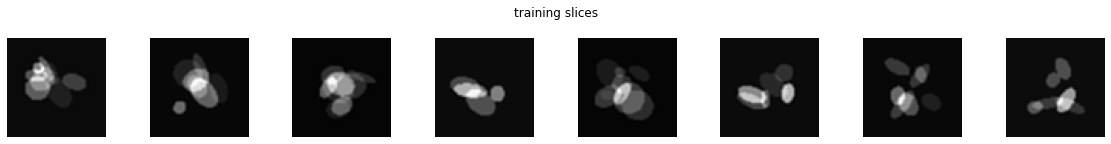

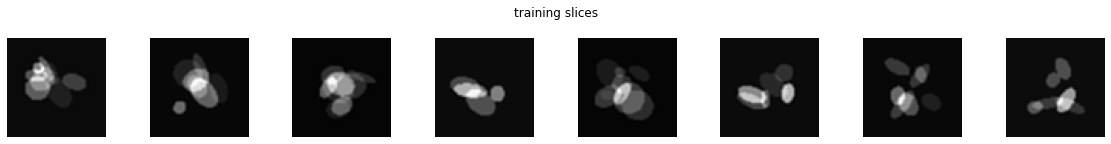

In [3]:

def show_images_grid(xs, title="", n=8):
    if not SHOW_PLOTS and not SAVE_FIGURES:
        return None
    xs = xs.detach().cpu()
    n = min(n, xs.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    if n == 1:
        axes = [axes]
    for ax, im in zip(axes, xs[:n]):
        ax.imshow(im[0], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "training_slices_preview.png", dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)
    return fig

show_images_grid(example_batch, "training slices", n=min(8, example_batch.shape[0]))


## 3. Score-prior network and DSM loss

The architecture and score target are unchanged. The only default change is that each minibatch time is sampled from a 2000-point grid rather than from a continuous uniform distribution.

With grid index \(j\in\{0,\ldots,1999\}\),

\[
t_j={\tt DSM\_T\_MIN}
+\frac{j}{1999}
({\tt DSM\_T\_MAX}-{\tt DSM\_T\_MIN}).
\]


In [4]:

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = int(dim)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,)
        half = self.dim // 2
        device = t.device
        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half, device=device))
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))
        return emb


class TimeBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        groups = 8 if out_ch % 8 == 0 else 1
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)
        return h + self.skip(x)


class SmallUNetScore(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)
        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)
        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)
        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        # t should be in [0,1], shape (B,)
        emb = self.time_mlp(t)
        e1 = self.enc1(x, emb)
        e2 = self.enc2(self.pool(e1), emb)
        e3 = self.enc3(self.pool(e2), emb)
        u2 = self.up2(e3)
        if u2.shape[-2:] != e2.shape[-2:]:
            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)
        u1 = self.up1(d2)
        if u1.shape[-2:] != e1.shape[-2:]:
            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)
        return self.out(d1)


def dsm_sigma(t: torch.Tensor) -> torch.Tensor:
    """Forward-noising sigma(t)=sqrt(t*(2-t)), unchanged from the SMC/DPS prior."""
    return torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8))


def dsm_time_grid(
    device: Optional[torch.device] = None,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """Return the explicit DSM training-time grid.

    The grid includes both DSM_T_MIN and DSM_T_MAX and contains exactly
    DSM_NUM_TIME_LEVELS entries.
    """
    if device is None:
        device = torch.device("cpu")
    return torch.linspace(
        float(DSM_T_MIN),
        float(DSM_T_MAX),
        int(DSM_NUM_TIME_LEVELS),
        device=device,
        dtype=dtype,
    )


def sample_dsm_times(
    batch_size: int,
    device: torch.device,
    dtype: torch.dtype = torch.float32,
):
    """Sample DSM times.

    Returns
    -------
    t:
        Tensor of shape (batch_size,).
    time_indices:
        Integer grid indices for discrete mode, otherwise None.
    """
    batch_size = int(batch_size)

    if DSM_TIME_SAMPLING_MODE == "continuous":
        t = (
            torch.rand(batch_size, device=device, dtype=dtype)
            * float(DSM_T_MAX - DSM_T_MIN)
            + float(DSM_T_MIN)
        )
        return t, None

    time_indices = torch.randint(
        low=0,
        high=int(DSM_NUM_TIME_LEVELS),
        size=(batch_size,),
        device=device,
    )
    fractions = time_indices.to(dtype=dtype) / float(DSM_NUM_TIME_LEVELS - 1)
    t = float(DSM_T_MIN) + fractions * float(DSM_T_MAX - DSM_T_MIN)
    return t, time_indices


def dsm_loss(model: nn.Module, x0: torch.Tensor) -> torch.Tensor:
    """Weighted DSM loss using continuous or explicit-grid time sampling."""
    B = int(x0.shape[0])
    t, _ = sample_dsm_times(
        batch_size=B,
        device=x0.device,
        dtype=x0.dtype,
    )
    sigma = dsm_sigma(t).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn_like(x0)
    xt = mean + sigma * eps

    # Exact conditional score of the Gaussian corruption.
    target = -eps / sigma
    pred = model(xt, t)

    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.mean()


@torch.no_grad()
def dsm_loss_fixed_time_per_sample(model, x0, t_value, generator):
    """Per-sample weighted DSM loss at a fixed forward-noising time."""
    B = x0.shape[0]
    t = torch.full((B,), float(t_value), device=x0.device, dtype=x0.dtype)
    sigma = dsm_sigma(t).view(B, 1, 1, 1)
    mean = (1.0 - t).view(B, 1, 1, 1) * x0
    eps = torch.randn(x0.shape, device=x0.device, dtype=x0.dtype, generator=generator)
    xt = mean + sigma * eps
    target = -eps / sigma
    pred = model(xt, t)
    sq = (pred - target) ** 2
    if DSM_WEIGHT_BY_SIGMA2:
        sq = sq * sigma ** 2
    return sq.flatten(1).mean(dim=1)


if DSM_TIME_SAMPLING_MODE == "discrete":
    _grid_preview = dsm_time_grid()
    print(
        "DSM grid:",
        f"{len(_grid_preview)} levels,",
        f"first={float(_grid_preview[0]):.8g},",
        f"last={float(_grid_preview[-1]):.8g},",
        f"spacing={float(_grid_preview[1] - _grid_preview[0]):.8g}",
    )
    del _grid_preview

score_model = SmallUNetScore(in_ch=1, base_ch=BASE_CHANNELS, emb_dim=TIME_EMB_DIM).to(DEVICE)
print("score model parameters:", sum(p.numel() for p in score_model.parameters()) / 1e6, "M")


DSM grid: 2000 levels, first=0.001, last=0.98000002, spacing=0.00048974494
score model parameters: 0.562625 M


## 4. Checkpoint loading

Default behavior for this DSM-2000 notebook:

- `RESUME_FROM_OUTPUT=True`: resume the DSM-2000 output checkpoint if it exists.
- `LOAD_PRETRAINED=False`: otherwise start from random initialization.
- Set `LOAD_PRETRAINED=True` and provide `PRETRAINED_CHECKPOINT_PATH` only for an intentional warm start from the earlier prior.

The network architecture is unchanged, so warm-starting is shape-compatible. The checkpoint records whether training used continuous or discrete time sampling.


In [5]:

def torch_load_checkpoint(path: pathlib.Path, map_location):
    try:
        return torch.load(str(path), map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location=map_location)


def extract_model_state(ckpt):
    if isinstance(ckpt, dict):
        for key in ("model", "model_state_dict", "state_dict", "net", "score_model"):
            if key in ckpt and isinstance(ckpt[key], dict):
                return ckpt[key]
    return ckpt


def maybe_strip_module_prefix(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    if not isinstance(state_dict, dict) or len(state_dict) == 0:
        return state_dict
    keys = list(state_dict.keys())
    if all(k.startswith("module.") for k in keys):
        return {k[len("module."):]: v for k, v in state_dict.items()}
    return state_dict


def load_model_weights(model: nn.Module, path: pathlib.Path, strict: bool = True):
    ckpt = torch_load_checkpoint(path, map_location=DEVICE)
    state = maybe_strip_module_prefix(extract_model_state(ckpt))
    load_result = model.load_state_dict(state, strict=strict)
    return ckpt, load_result


def extract_loss_history_and_steps(ckpt):
    if not isinstance(ckpt, dict):
        return [], []

    history = ckpt.get("loss_history", ckpt.get("training_losses", ckpt.get("score_training_losses", None)))
    steps = ckpt.get("loss_steps", ckpt.get("training_steps", ckpt.get("score_training_steps", None)))

    if history is None:
        return [], []
    if torch.is_tensor(history):
        history = history.detach().cpu().numpy()
    history = np.asarray(history, dtype=np.float64).reshape(-1).tolist()

    if steps is None:
        steps = list(range(1, len(history) + 1))
    elif torch.is_tensor(steps):
        steps = steps.detach().cpu().numpy()
    steps = np.asarray(steps, dtype=np.int64).reshape(-1).tolist()

    # Keep only aligned values.
    n = min(len(history), len(steps))
    return history[:n], steps[:n]


def report_checkpoint_time_sampling(ckpt, label: str):
    """Print the saved DSM time-sampling metadata when present."""
    if not isinstance(ckpt, dict):
        return
    cfg = ckpt.get("config", {})
    if not isinstance(cfg, dict):
        return
    saved_mode = cfg.get(
        "DSM_TIME_SAMPLING_MODE",
        cfg.get("training_time_sampling", {}).get("mode", "legacy/unknown"),
    )
    saved_levels = cfg.get(
        "DSM_NUM_TIME_LEVELS",
        cfg.get("training_time_sampling", {}).get("num_levels", None),
    )
    print(f"{label} DSM time mode:", saved_mode)
    print(f"{label} DSM time levels:", saved_levels)
    if saved_mode not in {"legacy/unknown", DSM_TIME_SAMPLING_MODE}:
        print(
            "WARNING: checkpoint time-sampling mode differs from the current run. "
            "This is allowed for an intentional warm start, but the saved model "
            "will become a fine-tuned grid model rather than a from-scratch grid model."
        )


optimizer = torch.optim.AdamW(score_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
score_training_losses = []
score_training_steps = []
new_run_losses = []
new_run_steps = []
checkpoint_loaded = False
checkpoint_source = "scratch initialization"
initial_global_step = 0

# Prefer output resume if present, otherwise load pretrained weights.
if RESUME_FROM_OUTPUT and OUTPUT_CHECKPOINT_PATH.exists():
    print(f"Resuming from output checkpoint: {OUTPUT_CHECKPOINT_PATH}")
    ckpt, load_result = load_model_weights(score_model, OUTPUT_CHECKPOINT_PATH, strict=STRICT_CHECKPOINT_LOAD)
    checkpoint_loaded = True
    checkpoint_source = f"resumed output checkpoint: {OUTPUT_CHECKPOINT_PATH}"
    if isinstance(ckpt, dict) and "optimizer" in ckpt:
        try:
            optimizer.load_state_dict(ckpt["optimizer"])
            print("Loaded optimizer state from output checkpoint.")
        except Exception as e:
            print("Could not load optimizer state; continuing with a fresh optimizer.")
            print("Optimizer load error:", repr(e))
    if KEEP_LOADED_LOSS_HISTORY:
        score_training_losses, score_training_steps = extract_loss_history_and_steps(ckpt)
    if isinstance(ckpt, dict):
        initial_global_step = int(ckpt.get("global_step", score_training_steps[-1] if score_training_steps else 0))
    report_checkpoint_time_sampling(ckpt, "resumed checkpoint")
    print("Loaded model weights successfully.")
elif LOAD_PRETRAINED and PRETRAINED_CHECKPOINT_PATH.exists():
    print(f"Loading pretrained weights: {PRETRAINED_CHECKPOINT_PATH}")
    ckpt, load_result = load_model_weights(score_model, PRETRAINED_CHECKPOINT_PATH, strict=STRICT_CHECKPOINT_LOAD)
    checkpoint_loaded = True
    checkpoint_source = f"pretrained checkpoint: {PRETRAINED_CHECKPOINT_PATH}"
    if KEEP_LOADED_LOSS_HISTORY:
        score_training_losses, score_training_steps = extract_loss_history_and_steps(ckpt)
    if score_training_steps:
        initial_global_step = int(score_training_steps[-1])
    report_checkpoint_time_sampling(ckpt, "warm-start checkpoint")
    print("Loaded pretrained model weights successfully.")
else:
    print("No checkpoint loaded; training starts from random initialization.")
    print("Set PRETRAINED_CHECKPOINT_PATH or OUTPUT_CHECKPOINT_PATH if you want to load pretrained weights.")

if not KEEP_LOADED_LOSS_HISTORY:
    score_training_losses = []
    score_training_steps = []
    initial_global_step = 0

print("checkpoint source:", checkpoint_source)
print("initial_global_step:", initial_global_step)
print("loaded loss values:", len(score_training_losses))
score_model.train()


Resuming from output checkpoint: mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
Loaded optimizer state from output checkpoint.
resumed checkpoint DSM time mode: discrete
resumed checkpoint DSM time levels: 2000
Loaded model weights successfully.
checkpoint source: resumed output checkpoint: mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
initial_global_step: 165000
loaded loss values: 165000


SmallUNetScore(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=128, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (enc1): TimeBlock(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
    (emb_proj): Linear(in_features=128, out_features=32, bias=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
    (skip): Conv2d(1, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (enc2): TimeBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (emb_proj): Linear(in_features=128, out_features=64, bias=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (

## 5. Train/fine-tune and save the prior

The x-axis of the loss plot is the optimizer iteration. The 2000 DSM time levels are sampled independently within each minibatch; they are **not** optimizer iterations.

The checkpoint stores the explicit time grid so downstream runs can verify how the prior was trained.


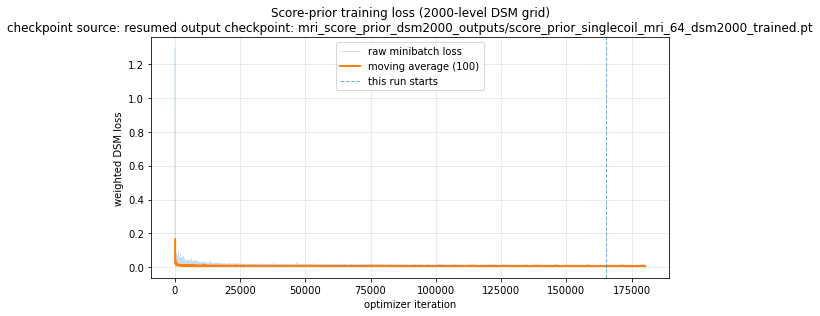

In [ ]:

def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


def moving_average_1d(values, window):
    values = np.asarray(values, dtype=np.float64)
    window = max(1, min(int(window), len(values))) if len(values) else 1
    if len(values) == 0 or window == 1:
        return values.copy()
    kernel = np.ones(window, dtype=np.float64) / float(window)
    return np.convolve(values, kernel, mode="valid")


def current_config_dict() -> Dict[str, Any]:
    return {
        "SEED": SEED,
        "DATA_MODE": DATA_MODE,
        "FASTMRI_TRAIN_ROOT": FASTMRI_TRAIN_ROOT,
        "FASTMRI_VAL_ROOT": FASTMRI_VAL_ROOT,
        "IMG_SIZE": IMG_SIZE,
        "SYNTHETIC_TRAIN_SIZE": SYNTHETIC_TRAIN_SIZE,
        "SYNTHETIC_VAL_SIZE": SYNTHETIC_VAL_SIZE,
        "BATCH_SIZE": BATCH_SIZE,
        "NUM_TRAIN_STEPS": NUM_TRAIN_STEPS,
        "LR": LR,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "GRAD_CLIP_NORM": GRAD_CLIP_NORM,
        "BASE_CHANNELS": BASE_CHANNELS,
        "TIME_EMB_DIM": TIME_EMB_DIM,
        "DSM_T_MIN": DSM_T_MIN,
        "DSM_T_MAX": DSM_T_MAX,
        "DSM_WEIGHT_BY_SIGMA2": DSM_WEIGHT_BY_SIGMA2,
        "DSM_TIME_SAMPLING_MODE": DSM_TIME_SAMPLING_MODE,
        "DSM_NUM_TIME_LEVELS": DSM_NUM_TIME_LEVELS,
        "training_time_sampling": {
            "mode": DSM_TIME_SAMPLING_MODE,
            "num_levels": DSM_NUM_TIME_LEVELS,
            "t_min": DSM_T_MIN,
            "t_max": DSM_T_MAX,
            "grid_includes_endpoints": True,
            "forward_mean": "(1-t)*x0",
            "forward_sigma": "sqrt(t*(2-t))",
        },
        "PRETRAINED_CHECKPOINT_PATH": str(PRETRAINED_CHECKPOINT_PATH),
        "OUTPUT_CHECKPOINT_PATH": str(OUTPUT_CHECKPOINT_PATH),
        "checkpoint_source": checkpoint_source,
        "terminal_time_dynamics": {
            "SAMPLER_TYPE": SAMPLER_TYPE,
            "T0": T0,
            "T1": T1,
            "BASE_NOISE_MODE": BASE_NOISE_MODE,
            "SAMPLE_CLAMP": SAMPLE_CLAMP,
            "NUM_REF_LEVELS": NUM_REF_LEVELS,
            "N_STEPS_REF_BY_LEVEL": N_STEPS_REF_BY_LEVEL,
            "N_STEPS_BASELINE_BY_LEVEL": N_STEPS_BASELINE_BY_LEVEL,
        },
        "prior_quality_metrics": {
            "RUN_PRIOR_QUALITY_METRICS": RUN_PRIOR_QUALITY_METRICS,
            "PRIOR_QUALITY_NUM_GENERATED": PRIOR_QUALITY_NUM_GENERATED,
            "PRIOR_QUALITY_NUM_REAL": PRIOR_QUALITY_NUM_REAL,
            "PRIOR_QUALITY_FEATURE_BACKEND": PRIOR_QUALITY_FEATURE_BACKEND,
            "PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD": PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD,
            "PRIOR_QUALITY_DCT_SIZE": PRIOR_QUALITY_DCT_SIZE,
            "PRIOR_QUALITY_KID_SUBSETS": PRIOR_QUALITY_KID_SUBSETS,
            "PRIOR_QUALITY_KID_SUBSET_SIZE": PRIOR_QUALITY_KID_SUBSET_SIZE,
        },
        "tail_diagnostics": {
            "RUN_TAIL_STATS": RUN_TAIL_STATS,
            "N_REF_TAIL": N_REF_TAIL,
            "NUM_TAIL_LEVELS": NUM_TAIL_LEVELS,
            "TAIL_STATS_CHUNK_SIZE": TAIL_STATS_CHUNK_SIZE,
            "USE_MONOTONE_GAP": USE_MONOTONE_GAP,
        },
    }


def save_prior_checkpoint(path: pathlib.Path, global_step: int):
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "model": score_model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "global_step": int(global_step),
        "config": current_config_dict(),
        "loss_history": torch.as_tensor(score_training_losses, dtype=torch.float32),
        "loss_steps": torch.as_tensor(score_training_steps, dtype=torch.int64),
        "new_run_loss_history": torch.as_tensor(new_run_losses, dtype=torch.float32),
        "new_run_loss_steps": torch.as_tensor(new_run_steps, dtype=torch.int64),
        "dsm_time_grid": (
            dsm_time_grid(device=torch.device("cpu"), dtype=torch.float32)
            if DSM_TIME_SAMPLING_MODE == "discrete"
            else None
        ),
        "saved_at_unix_time": time.time(),
    }
    torch.save(payload, str(path))
    return path


def save_loss_csv(path: pathlib.Path):
    if len(score_training_losses) == 0:
        return None
    arr = np.column_stack([
        np.asarray(score_training_steps, dtype=np.int64),
        np.asarray(score_training_losses, dtype=np.float64),
    ])
    np.savetxt(path, arr, delimiter=",", header="iteration,weighted_dsm_loss", comments="")
    return path


def save_dsm_time_grid_csv(path: pathlib.Path):
    """Save the explicit discrete DSM grid for reproducibility."""
    if DSM_TIME_SAMPLING_MODE != "discrete":
        return None
    grid = dsm_time_grid(device=torch.device("cpu"), dtype=torch.float64).numpy()
    arr = np.column_stack([
        np.arange(len(grid), dtype=np.int64),
        grid,
    ])
    np.savetxt(
        path,
        arr,
        delimiter=",",
        header="time_index,t_forward",
        comments="",
    )
    return path


def plot_loss_history(save_path: Optional[pathlib.Path] = None, title_suffix: str = ""):
    fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
    if len(score_training_losses) == 0:
        ax.text(0.5, 0.5, "No loss values recorded yet", ha="center", va="center")
        ax.set_axis_off()
    else:
        steps = np.asarray(score_training_steps, dtype=np.int64)
        losses = np.asarray(score_training_losses, dtype=np.float64)
        ax.plot(steps, losses, alpha=0.25, linewidth=0.8, label="raw minibatch loss")
        smooth = moving_average_1d(losses, TRAIN_LOSS_SMOOTH_WINDOW)
        smooth_steps = steps[len(steps) - len(smooth):]
        ax.plot(smooth_steps, smooth, linewidth=2.0,
                label=f"moving average ({min(TRAIN_LOSS_SMOOTH_WINDOW, len(losses))})")
        if len(new_run_steps) > 0:
            ax.axvline(new_run_steps[0], linestyle="--", linewidth=1.0, alpha=0.6, label="this run starts")
        time_label = (
            f"{DSM_NUM_TIME_LEVELS}-level DSM grid"
            if DSM_TIME_SAMPLING_MODE == "discrete"
            else "continuous-time DSM"
        )
        ax.set_title("Score-prior training loss (" + time_label + ")" + title_suffix)
        ax.set_xlabel("optimizer iteration")
        ax.set_ylabel("weighted DSM loss")
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    return fig


def maybe_display_live_loss(local_step: int):
    if not (SHOW_PLOTS and PLOT_SCORE_TRAINING_LOSS and PLOT_DURING_TRAINING and HAVE_IPYTHON_DISPLAY):
        return
    if local_step == 1 or local_step % max(1, PLOT_EVERY) == 0 or local_step == NUM_TRAIN_STEPS:
        clear_output(wait=True)
        fig = plot_loss_history(title_suffix=f"\ncheckpoint source: {checkpoint_source}")
        display(fig)
        plt.close(fig)


data_iter = infinite_loader(train_loader)
score_model.train()
last_global_step = int(initial_global_step)

if NUM_TRAIN_STEPS <= 0:
    print("NUM_TRAIN_STEPS <= 0, so no optimizer updates were run.")
else:
    pbar = tqdm(range(1, NUM_TRAIN_STEPS + 1), desc="training score prior")
    for local_step in pbar:
        global_step = int(initial_global_step + local_step)
        x0 = next(data_iter).to(DEVICE, non_blocking=PIN_MEMORY)
        loss = dsm_loss(score_model, x0)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            torch.nn.utils.clip_grad_norm_(score_model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        loss_float = float(loss.detach().cpu())
        score_training_losses.append(loss_float)
        score_training_steps.append(global_step)
        new_run_losses.append(loss_float)
        new_run_steps.append(global_step)
        last_global_step = global_step

        if local_step % 50 == 0 or local_step == 1:
            tail = new_run_losses[-min(50, len(new_run_losses)):]
            pbar.set_postfix({"loss_50avg": float(np.mean(tail)), "global_step": global_step})

        if local_step % 500 == 0:
            clear_device_cache()

        if SAVE_CHECKPOINT and SAVE_EVERY > 0 and local_step % SAVE_EVERY == 0:
            save_prior_checkpoint(OUTPUT_CHECKPOINT_PATH, global_step=last_global_step)
            save_loss_csv(OUTPUT_DIR / "score_prior_training_loss.csv")
            if SAVE_INTERMEDIATE_COPIES:
                step_path = OUTPUT_CHECKPOINT_PATH.with_name(
                    OUTPUT_CHECKPOINT_PATH.stem + f"_step{global_step}" + OUTPUT_CHECKPOINT_PATH.suffix
                )
                save_prior_checkpoint(step_path, global_step=last_global_step)

        maybe_display_live_loss(local_step)

sync_device()
score_model.eval()
clear_device_cache()

if SAVE_CHECKPOINT:
    final_ckpt_path = save_prior_checkpoint(OUTPUT_CHECKPOINT_PATH, global_step=last_global_step)
    print(f"Saved final checkpoint: {final_ckpt_path}")

loss_csv_path = save_loss_csv(OUTPUT_DIR / "score_prior_training_loss.csv")
if loss_csv_path is not None:
    print(f"Saved loss CSV: {loss_csv_path}")

if SAVE_DSM_TIME_GRID:
    dsm_grid_csv_path = save_dsm_time_grid_csv(OUTPUT_DIR / "dsm_time_grid.csv")
    if dsm_grid_csv_path is not None:
        print(f"Saved DSM time grid CSV: {dsm_grid_csv_path}")

if PLOT_SCORE_TRAINING_LOSS:
    loss_plot_path = (OUTPUT_DIR / "score_prior_training_loss.png") if SAVE_FIGURES else None
    fig = plot_loss_history(
        save_path=loss_plot_path,
        title_suffix=f"\ncheckpoint source: {checkpoint_source}",
    )
    if SAVE_FIGURES:
        # Same figure under an explicit name for easy lookup.
        fig.savefig(OUTPUT_DIR / "loss_vs_optimizer_iteration.png", dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)
    if SAVE_FIGURES:
        print(f"Saved loss plot: {OUTPUT_DIR / 'score_prior_training_loss.png'}")
        print(f"Saved loss-vs-iteration plot: {OUTPUT_DIR / 'loss_vs_optimizer_iteration.png'}")

print("Training updates run in this notebook:", len(new_run_losses))
print("Total recorded loss values:", len(score_training_losses))
print("Last global step:", last_global_step)
print("DSM time sampling mode:", DSM_TIME_SAMPLING_MODE)
print("DSM number of time levels:", DSM_NUM_TIME_LEVELS)


## 6. Optional held-out DSM loss by noising time

This evaluates the same DSM objective at fixed forward-noising times. The evaluation points need not coincide exactly with training-grid points; the sinusoidal time embedding provides interpolation between the dense 2000 training levels.


In [ ]:

score_validation_time_grid = np.asarray([], dtype=np.float64)
score_validation_time_loss = np.asarray([], dtype=np.float64)

if TRAIN_LOSS_TIME_BINS > 0 and TRAIN_LOSS_EVAL_BATCHES > 0:
    score_model.eval()
    score_validation_time_grid = np.linspace(DSM_T_MIN, DSM_T_MAX, TRAIN_LOSS_TIME_BINS)
    time_losses = []

    for t_idx, t_value in enumerate(score_validation_time_grid):
        vals = []
        generator = torch.Generator(device=DEVICE)
        generator.manual_seed(SEED + 70000 + t_idx)
        for batch_idx, batch in enumerate(val_loader):
            if batch_idx >= TRAIN_LOSS_EVAL_BATCHES:
                break
            x0 = batch.to(DEVICE, non_blocking=PIN_MEMORY)
            vals.append(dsm_loss_fixed_time_per_sample(score_model, x0, t_value, generator).detach().cpu())
        time_losses.append(float(torch.cat(vals).mean()) if vals else float("nan"))

    score_validation_time_loss = np.asarray(time_losses, dtype=np.float64)

print("Training dataset class:", type(train_ds).__name__)
print("Validation dataset class:", type(val_ds).__name__)
print("Recorded optimizer losses:", int(len(score_training_losses)))
if score_validation_time_loss.size:
    print("Fixed-time DSM loss mean/min/max:",
          float(np.nanmean(score_validation_time_loss)),
          float(np.nanmin(score_validation_time_loss)),
          float(np.nanmax(score_validation_time_loss)))

if PLOT_SCORE_TRAINING_LOSS and score_validation_time_loss.size:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(score_validation_time_grid, score_validation_time_loss, marker="o")
    ax.set_title("Held-out DSM loss by noising time")
    ax.set_xlabel("forward noising time t")
    ax.set_ylabel("weighted DSM loss")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / "score_prior_fixed_time_dsm_loss.png", dpi=160, bbox_inches="tight")
        np.savetxt(
            OUTPUT_DIR / "score_prior_fixed_time_dsm_loss.csv",
            np.column_stack([score_validation_time_grid, score_validation_time_loss]),
            delimiter=",",
            header="t,weighted_dsm_loss",
            comments="",
        )
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


## 7. Terminal multiscale prior dynamics and optional preview

The terminal multiscale sampler is unchanged. It still queries the learned score at continuous forward times \(1-t\). A 2000-point training grid is dense enough for the time-embedding network to interpolate, so the existing SMC/DPS dynamics remain compatible.


In [ ]:

# ============================================================
# Manuscript-style terminal multiscale SDE simulator for images
# ============================================================
# Every level is a terminal partial sum S_m = sum_{k=0}^m Xbar^k_1.
# Selection is always performed on terminal samples, not intermediate reverse-time checkpoints.


def make_generator(seed: int, device=DEVICE):
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))
    return gen


@torch.no_grad()
def randn_seeded(shape, seed: int, device=DEVICE, dtype=torch.float32):
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


@torch.no_grad()
def score_apply_torch(tau_forward: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Apply learned score. tau_forward is the forward noising time in [0,1]."""
    if not torch.is_tensor(tau_forward):
        tau_forward = torch.full((x.shape[0],), float(tau_forward), device=x.device, dtype=x.dtype)
    elif tau_forward.ndim == 0:
        tau_forward = torch.full((x.shape[0],), float(tau_forward.item()), device=x.device, dtype=x.dtype)
    return score_model(x, torch.clamp(tau_forward.to(x.device, x.dtype), min=DSM_T_MIN, max=DSM_T_MAX))


@torch.no_grad()
def base_drift_torch(t: float, y: torch.Tensor) -> torch.Tensor:
    """Reverse-SDE drift used in the multiscale increment decomposition."""
    t_safe = torch.clamp(torch.as_tensor(t, device=y.device, dtype=y.dtype), min=1e-4)
    score_time = torch.clamp(1.0 - t_safe, min=DSM_T_MIN, max=DSM_T_MAX)
    score = score_apply_torch(score_time, y)
    # Manuscript SDE drift: (x + 2 score)/t. Noise is represented separately by the level expansion.
    return (y + 2.0 * score) / t_safe


def psi_pair_torch(t, n, k):
    d = 2.0 ** (-(n - 1))
    I0 = (k - 1) * d
    I1 = k * d
    I2 = (k + 1) * d
    scale = 2.0 ** ((n - 2) / 2.0)
    tf = float(t)
    val = torch.zeros((2,), device=DEVICE)
    if (tf > I0) and (tf < I1):
        val[0] = scale
    elif (tf > I1) and (tf < I2):
        val[1] = -scale
    return val


def white_level_coeffs_torch(t, n_level):
    if n_level == 1:
        return torch.ones((1,), device=DEVICE)
    num_k_iter = 2 ** (n_level - 2)
    vals = []
    for kk in range(num_k_iter):
        k = 2 * kk + 1
        vals.append(psi_pair_torch(t, n_level, k))
    psi_flat = torch.cat(vals, dim=0)
    scal = 2.0 ** (-(n_level) / 2.0)
    return psi_flat * scal


def generate_eta_tensor_torch(max_n, batch_size, image_shape, seed):
    num_k = 2 ** (max_n - 1)
    return randn_seeded((batch_size, num_k, *image_shape), seed=seed, device=DEVICE)


def white_level_vector_torch(t, n_level, eta_batch):
    t_safe = torch.clamp(torch.as_tensor(t, device=DEVICE, dtype=eta_batch.dtype), min=1e-4)
    coeffs = white_level_coeffs_torch(float(t_safe), n_level).to(dtype=eta_batch.dtype)
    # coeffs: (K,), eta_batch: (B,K,C,H,W) -> (B,C,H,W)
    noise = torch.tensordot(coeffs, eta_batch, dims=([0], [1]))
    return noise * torch.sqrt(2.0 / t_safe)


@torch.no_grad()
def interpolate_paths_to_n_steps_torch(paths: torch.Tensor, target_n_steps: int) -> torch.Tensor:
    """Interpolate a full path to a new uniform grid on [T0,T1].

    paths has shape (old_steps+1, B, C, H, W).
    """
    old_n_steps = int(paths.shape[0] - 1)
    target_n_steps = int(target_n_steps)
    if old_n_steps == target_n_steps:
        return paths
    pos = torch.linspace(0.0, float(old_n_steps), target_n_steps + 1, device=paths.device)
    lo = torch.floor(pos).long().clamp(0, old_n_steps)
    hi = torch.ceil(pos).long().clamp(0, old_n_steps)
    w = (pos - lo.to(dtype=paths.dtype)).view(-1, 1, 1, 1, 1)
    return (1.0 - w) * paths[lo] + w * paths[hi]


@torch.no_grad()
def simulate_base_level_torch(seed: int, batch_size: int, n_steps: int, t0: float = T0, t1: float = T1) -> torch.Tensor:
    """Simulate base terminal path Xbar^0_t on [T0,T1]."""
    n_steps = int(n_steps)
    x = randn_seeded((batch_size, 1, IMG_SIZE, IMG_SIZE), seed=seed, device=DEVICE)
    omega0 = randn_seeded((batch_size, 1, IMG_SIZE, IMG_SIZE), seed=seed + 1, device=DEVICE)
    ts = torch.linspace(float(t0), float(t1), n_steps + 1, device=DEVICE)
    dt = float(t1 - t0) / float(n_steps)
    xs = [x.clone()]
    for k in range(n_steps):
        t = ts[k]
        drift = base_drift_torch(float(t.item()), x)
        if BASE_NOISE_MODE == "sqrt_2_over_t":
            noise = torch.sqrt(2.0 / torch.clamp(t, min=1e-4)) * omega0
        else:
            noise = omega0
        x = x + dt * (drift + noise)
        if SAMPLE_CLAMP is not None:
            x = torch.clamp(x, -SAMPLE_CLAMP, SAMPLE_CLAMP)
        xs.append(x.clone())
    return torch.stack(xs, dim=0)


@torch.no_grad()
def increment_drift_torch(t: float, y: torch.Tensor, x_base: torch.Tensor) -> torch.Tensor:
    return base_drift_torch(t, x_base + y) - base_drift_torch(t, x_base)


@torch.no_grad()
def simulate_increment_level_torch(
    seed: int,
    noise_level: int,
    current_paths: torch.Tensor,
    n_steps: int,
    t0: float = T0,
    t1: float = T1,
    return_base_on_grid: bool = False,
):
    """Simulate increment Xbar^noise_level_t over the full terminal interval.

    current_paths represents S_{level-1}(t). The returned increment path has terminal value
    Xbar^level_1, so current_on_grid + inc_paths is S_level(t).
    """
    n_steps = int(n_steps)
    batch_size = int(current_paths.shape[1])
    image_shape = tuple(current_paths.shape[2:])
    current_on_grid = interpolate_paths_to_n_steps_torch(current_paths, n_steps)
    eta_batch = generate_eta_tensor_torch(noise_level, batch_size, image_shape, seed)
    y = torch.zeros((batch_size, *image_shape), device=DEVICE, dtype=current_paths.dtype)
    ts = torch.linspace(float(t0), float(t1), n_steps + 1, device=DEVICE)
    dt = float(t1 - t0) / float(n_steps)
    ys = [y.clone()]
    for k in range(n_steps):
        t = ts[k]
        x_base = current_on_grid[k]
        drift = increment_drift_torch(float(t.item()), y, x_base)
        noise = white_level_vector_torch(float(t.item()), noise_level, eta_batch)
        y = y + dt * (drift + noise)
        if SAMPLE_CLAMP is not None:
            # Clamp the total state, then convert back to increment coordinates.
            total = torch.clamp(x_base + y, -SAMPLE_CLAMP, SAMPLE_CLAMP)
            y = total - x_base
        ys.append(y.clone())
    inc_paths = torch.stack(ys, dim=0)
    if return_base_on_grid:
        return inc_paths, current_on_grid
    return inc_paths


@torch.no_grad()
def simulate_prior_hierarchy_with_increments_torch(
    seed: int,
    batch_size: int,
    num_levels: int,
    n_steps_by_level,
    t0: float = T0,
    t1: float = T1,
):
    """Generate terminal multiscale hierarchy.

    Returns:
        paths_by_level[ell]      : full path for S_ell(t), terminal sample is paths_by_level[ell][-1]
        increments_by_level[ell] : full path for Xbar^ell(t)
    """
    steps = [int(s) for s in list(n_steps_by_level)]
    if len(steps) != int(num_levels):
        raise ValueError(f"n_steps_by_level must have length {num_levels}, got {len(steps)}")
    paths_by_level = []
    increments_by_level = []
    current_paths = simulate_base_level_torch(seed, batch_size, n_steps=steps[0], t0=t0, t1=t1)
    paths_by_level.append(current_paths)
    increments_by_level.append(current_paths)
    for ell in range(1, int(num_levels)):
        inc_paths, current_on_grid = simulate_increment_level_torch(
            seed + 1000 * ell,
            ell + 1,
            current_paths,
            n_steps=steps[ell],
            t0=t0,
            t1=t1,
            return_base_on_grid=True,
        )
        current_paths = current_on_grid + inc_paths
        if SAMPLE_CLAMP is not None:
            current_paths = torch.clamp(current_paths, -SAMPLE_CLAMP, SAMPLE_CLAMP)
        paths_by_level.append(current_paths)
        increments_by_level.append(inc_paths)
    return paths_by_level, increments_by_level


@torch.no_grad()
def sample_prior_terminal(model: nn.Module, batch_size: int, chunk_size: int = SAMPLE_CHUNK_SIZE) -> torch.Tensor:
    """Reference-level terminal prior sampler: returns S_ref = S_{NUM_REF_LEVELS-1}(1)."""
    model.eval()
    chunks = []
    done = 0
    while done < int(batch_size):
        bs = min(int(chunk_size), int(batch_size) - done)
        paths, _ = simulate_prior_hierarchy_with_increments_torch(
            seed=SEED + 910000 + done,
            batch_size=bs,
            num_levels=NUM_REF_LEVELS,
            n_steps_by_level=N_STEPS_BASELINE_BY_LEVEL,
            t0=T0,
            t1=T1,
        )
        chunks.append(paths[-1][-1].detach().cpu())
        done += bs
        del paths
        clear_device_cache()
    return torch.cat(chunks, dim=0).to(DEVICE)


print("Terminal multiscale prior simulator defined.")
print("Selection is at terminal time T1, not at intermediate reverse times.")
print("T0/T1:", T0, T1)
print("NUM_REF_LEVELS:", NUM_REF_LEVELS)
print("Reference terminal steps:", N_STEPS_REF_BY_LEVEL)

if RUN_PRIOR_PREVIEW:
    with torch.no_grad():
        prior_preview = sample_prior_terminal(score_model, batch_size=PRIOR_PREVIEW_BATCH_SIZE)
    show_images_grid(prior_preview, "reference-level prior samples S_ref", n=min(10, prior_preview.shape[0]))
else:
    print("RUN_PRIOR_PREVIEW=False, so prior sampling preview was skipped.")


## 8. Optional terminal-tail behavior statistics

This cell estimates how much terminal tail remains when a lower terminal partial sum $S_m(T_1)$ is compared with the reference sample $S_{\rm ref}(T_1)=S_{M-1}(T_1)$. It saves summary statistics, the mean tail maps, and plots of tail variance / gap / eta versus terminal level.

Set `RUN_TAIL_STATS=0` to skip it, or increase `N_REF_TAIL` for a larger Monte Carlo estimate.

In [ ]:

# ============================================================
# Optional tail-behavior statistics for terminal partial sums
# ============================================================
# Tail at level m is R_m = S_ref(T1) - S_m(T1), where S_ref is the
# highest reference terminal level produced by NUM_REF_LEVELS.


def _trace_var_per_dim_from_sums(sum_x: torch.Tensor, sum_x2: torch.Tensor, n: int) -> torch.Tensor:
    mean = sum_x / float(n)
    mean2 = sum_x2 / float(n)
    var = torch.clamp(mean2 - mean ** 2, min=0.0)
    return var.mean()


def _safe_quantiles(values: np.ndarray, qs=(0.5, 0.9, 0.95, 0.99)) -> Dict[str, float]:
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    if values.size == 0:
        return {f"q{int(q * 100):02d}": float("nan") for q in qs}
    out = {}
    for q in qs:
        out[f"q{int(q * 100):02d}"] = float(np.quantile(values, q))
    return out


@torch.no_grad()
def build_terminal_tail_statistics(
    model: nn.Module,
    n_ref_tail: int = N_REF_TAIL,
    num_tail_levels: int = NUM_TAIL_LEVELS,
    chunk_size: int = TAIL_STATS_CHUNK_SIZE,
    capture_reference_samples: bool = False,
    max_reference_samples: int = 0,
):
    """Streaming terminal-tail statistics.

    For each Monte Carlo draw, generate S_0,...,S_{NUM_REF_LEVELS-1} at terminal
    time T1. For levels m < num_tail_levels, compute R_m = S_ref - S_m.
    """
    n_ref_tail = int(n_ref_tail)
    num_tail_levels = int(num_tail_levels)
    chunk_size = max(1, int(chunk_size))
    if n_ref_tail <= 0:
        raise ValueError("N_REF_TAIL must be positive when RUN_TAIL_STATS=True")
    if num_tail_levels < 1 or num_tail_levels > NUM_REF_LEVELS:
        raise ValueError(f"num_tail_levels must be in [1,{NUM_REF_LEVELS}], got {num_tail_levels}")

    model.eval()
    shape = (1, 1, IMG_SIZE, IMG_SIZE)
    sum_ref = torch.zeros(shape, dtype=torch.float64)
    sum_ref2 = torch.zeros(shape, dtype=torch.float64)
    sum_level = [torch.zeros(shape, dtype=torch.float64) for _ in range(num_tail_levels)]
    sum_level2 = [torch.zeros(shape, dtype=torch.float64) for _ in range(num_tail_levels)]
    sum_tail = [torch.zeros(shape, dtype=torch.float64) for _ in range(num_tail_levels)]
    sum_tail2 = [torch.zeros(shape, dtype=torch.float64) for _ in range(num_tail_levels)]

    tail_rms_per_sample = [[] for _ in range(num_tail_levels)]
    tail_mae_per_sample = [[] for _ in range(num_tail_levels)]
    tail_maxabs_per_sample = [[] for _ in range(num_tail_levels)]
    reference_sample_chunks = []
    captured_reference_count = 0
    max_reference_samples = max(0, int(max_reference_samples))

    count = 0
    pbar = tqdm(range(0, n_ref_tail, chunk_size), desc="terminal tail stats", leave=False)
    for start in pbar:
        bs = min(chunk_size, n_ref_tail - int(start))
        paths_ref, increments_ref = simulate_prior_hierarchy_with_increments_torch(
            seed=SEED + 700000 + int(start),
            batch_size=bs,
            num_levels=NUM_REF_LEVELS,
            n_steps_by_level=N_STEPS_REF_BY_LEVEL,
            t0=T0,
            t1=T1,
        )
        finals_cpu = [p[-1].detach().cpu().to(torch.float64) for p in paths_ref]
        x_ref = finals_cpu[-1]
        if capture_reference_samples and captured_reference_count < max_reference_samples:
            take = min(int(x_ref.shape[0]), max_reference_samples - captured_reference_count)
            if take > 0:
                reference_sample_chunks.append(x_ref[:take].to(torch.float32).clone())
                captured_reference_count += take
        sum_ref += x_ref.sum(dim=0, keepdim=True)
        sum_ref2 += (x_ref ** 2).sum(dim=0, keepdim=True)

        for m in range(num_tail_levels):
            xm = finals_cpu[m]
            tail = x_ref - xm
            flat = tail.flatten(1)
            abs_flat = flat.abs()

            sum_level[m] += xm.sum(dim=0, keepdim=True)
            sum_level2[m] += (xm ** 2).sum(dim=0, keepdim=True)
            sum_tail[m] += tail.sum(dim=0, keepdim=True)
            sum_tail2[m] += (tail ** 2).sum(dim=0, keepdim=True)

            tail_rms_per_sample[m].append(torch.sqrt(torch.clamp((flat ** 2).mean(dim=1), min=0.0)).numpy())
            tail_mae_per_sample[m].append(abs_flat.mean(dim=1).numpy())
            tail_maxabs_per_sample[m].append(abs_flat.amax(dim=1).numpy())

        count += bs
        del paths_ref, increments_ref, finals_cpu, x_ref
        clear_device_cache()

    var_ref = _trace_var_per_dim_from_sums(sum_ref, sum_ref2, count)
    mu_tails = []
    eta_by_level = []
    level_vars = []
    tail_vars = []
    gap_vars = []
    rows = []

    for m in range(num_tail_levels):
        mu = (sum_tail[m] / float(count)).to(torch.float32)
        mu_tails.append(mu.detach())
        var_m = float(_trace_var_per_dim_from_sums(sum_level[m], sum_level2[m], count).cpu())
        var_tail = float(_trace_var_per_dim_from_sums(sum_tail[m], sum_tail2[m], count).cpu())
        gap = max(float(var_ref.cpu()) - var_m, 0.0)
        level_vars.append(var_m)
        tail_vars.append(var_tail)
        gap_vars.append(gap)

    if USE_MONOTONE_GAP:
        gap_vars = [float(x) for x in np.minimum.accumulate(np.asarray(gap_vars, dtype=np.float64))]

    for m in range(num_tail_levels):
        tv = max(float(tail_vars[m]), 1e-12)
        eta = math.sqrt(max(float(gap_vars[m]), 0.0) / tv)
        eta_by_level.append(float(eta))

        rms = np.concatenate(tail_rms_per_sample[m], axis=0)
        mae = np.concatenate(tail_mae_per_sample[m], axis=0)
        maxabs = np.concatenate(tail_maxabs_per_sample[m], axis=0)
        rms_q = _safe_quantiles(rms)
        mae_q = _safe_quantiles(mae)
        maxabs_q = _safe_quantiles(maxabs)

        rows.append({
            "level_zero_based": int(m),
            "level_one_based": int(m + 1),
            "n_ref_tail": int(count),
            "level_var_per_dim": float(level_vars[m]),
            "tail_var_per_dim": float(tail_vars[m]),
            "gap_var_per_dim": float(gap_vars[m]),
            "eta": float(eta_by_level[m]),
            "tail_mean_map_rms": float(torch.sqrt(torch.clamp((mu_tails[m] ** 2).mean(), min=0.0)).cpu()),
            "tail_rms_mean": float(np.mean(rms)),
            "tail_rms_q50": rms_q["q50"],
            "tail_rms_q90": rms_q["q90"],
            "tail_rms_q95": rms_q["q95"],
            "tail_rms_q99": rms_q["q99"],
            "tail_mae_mean": float(np.mean(mae)),
            "tail_mae_q95": mae_q["q95"],
            "tail_mae_q99": mae_q["q99"],
            "tail_maxabs_mean": float(np.mean(maxabs)),
            "tail_maxabs_q95": maxabs_q["q95"],
            "tail_maxabs_q99": maxabs_q["q99"],
        })

    sample_traces = {
        "tail_rms_per_sample": np.stack([np.concatenate(v, axis=0) for v in tail_rms_per_sample], axis=0),
        "tail_mae_per_sample": np.stack([np.concatenate(v, axis=0) for v in tail_mae_per_sample], axis=0),
        "tail_maxabs_per_sample": np.stack([np.concatenate(v, axis=0) for v in tail_maxabs_per_sample], axis=0),
    }

    info = {
        "eta_by_level": eta_by_level,
        "tail_vars": tail_vars,
        "level_vars": level_vars,
        "gap_vars": gap_vars,
        "var_ref": float(var_ref.cpu()),
        "n_ref_tail": int(count),
        "num_tail_levels": int(num_tail_levels),
        "num_ref_levels": int(NUM_REF_LEVELS),
        "reference_level_one_based": int(NUM_REF_LEVELS),
        "tail_level_one_based": list(range(1, num_tail_levels + 1)),
        "T0": float(T0),
        "T1": float(T1),
        "N_STEPS_REF_BY_LEVEL": [int(s) for s in N_STEPS_REF_BY_LEVEL],
        "USE_MONOTONE_GAP": bool(USE_MONOTONE_GAP),
    }
    reference_samples = (
        torch.cat(reference_sample_chunks, dim=0)
        if len(reference_sample_chunks) > 0
        else None
    )
    return mu_tails, rows, info, sample_traces, reference_samples


def save_tail_behavior_outputs(mu_tails, rows, info, sample_traces):
    csv_path = OUTPUT_DIR / "score_prior_tail_behavior_summary.csv"
    json_path = OUTPUT_DIR / "score_prior_tail_behavior_summary.json"
    npz_path = OUTPUT_DIR / "score_prior_tail_behavior_stats.npz"
    variance_plot_path = OUTPUT_DIR / "score_prior_tail_behavior_variance.png"
    eta_plot_path = OUTPUT_DIR / "score_prior_tail_behavior_eta.png"

    # Save compact CSV summary without requiring pandas.
    fieldnames = list(rows[0].keys()) if rows else []
    if rows:
        with open(csv_path, "w", encoding="utf-8") as f:
            f.write(",".join(fieldnames) + "\n")
            for row in rows:
                f.write(",".join(str(row[name]) for name in fieldnames) + "\n")

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump({"info": info, "summary_rows": rows}, f, indent=2)

    np.savez_compressed(
        npz_path,
        mu_tail_by_level=np.stack([mu.detach().cpu().numpy() for mu in mu_tails], axis=0),
        eta_by_level=np.asarray(info["eta_by_level"], dtype=np.float64),
        tail_vars=np.asarray(info["tail_vars"], dtype=np.float64),
        level_vars=np.asarray(info["level_vars"], dtype=np.float64),
        gap_vars=np.asarray(info["gap_vars"], dtype=np.float64),
        tail_rms_per_sample=sample_traces["tail_rms_per_sample"],
        tail_mae_per_sample=sample_traces["tail_mae_per_sample"],
        tail_maxabs_per_sample=sample_traces["tail_maxabs_per_sample"],
        info=np.asarray([info], dtype=object),
        summary_rows=np.asarray([rows], dtype=object),
    )

    levels = np.asarray(info["tail_level_one_based"], dtype=np.int64)
    tail_vars = np.asarray(info["tail_vars"], dtype=np.float64)
    gap_vars = np.asarray(info["gap_vars"], dtype=np.float64)
    level_vars = np.asarray(info["level_vars"], dtype=np.float64)
    eta = np.asarray(info["eta_by_level"], dtype=np.float64)

    fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
    ax.plot(levels, level_vars, marker="o", label="Var[S_m] per pixel")
    ax.plot(levels, tail_vars, marker="o", label="Var[S_ref - S_m] per pixel")
    ax.plot(levels, gap_vars, marker="o", label="max(Var[S_ref]-Var[S_m],0)")
    if np.all(np.isfinite(tail_vars)) and np.nanmax(np.r_[tail_vars, gap_vars, level_vars]) > 0:
        ax.set_yscale("log")
    ax.set_title("Terminal tail behavior by partial-sum level")
    ax.set_xlabel("terminal partial-sum level m+1")
    ax.set_ylabel("variance per pixel")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(variance_plot_path, dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

    fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
    ax.plot(levels, eta, marker="o")
    ax.set_title("Terminal tail correction scale eta by level")
    ax.set_xlabel("terminal partial-sum level m+1")
    ax.set_ylabel("eta")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(eta_plot_path, dpi=160, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)

    return {
        "csv": csv_path,
        "json": json_path,
        "npz": npz_path,
        "variance_plot": variance_plot_path,
        "eta_plot": eta_plot_path,
    }


tail_behavior_paths = {}
tail_reference_samples = None
if RUN_TAIL_STATS:
    t_start = time.time()
    _capture_tail_reference_for_metrics = bool(
        RUN_PRIOR_QUALITY_METRICS
        and PRIOR_QUALITY_NUM_GENERATED <= N_REF_TAIL
    )
    mu_tail_by_level, tail_summary_rows, tail_behavior_info, tail_sample_traces, tail_reference_samples = build_terminal_tail_statistics(
        score_model,
        n_ref_tail=N_REF_TAIL,
        num_tail_levels=NUM_TAIL_LEVELS,
        chunk_size=TAIL_STATS_CHUNK_SIZE,
        capture_reference_samples=_capture_tail_reference_for_metrics,
        max_reference_samples=(
            PRIOR_QUALITY_NUM_GENERATED
            if _capture_tail_reference_for_metrics
            else 0
        ),
    )
    sync_device()
    tail_behavior_paths = save_tail_behavior_outputs(
        mu_tail_by_level,
        tail_summary_rows,
        tail_behavior_info,
        tail_sample_traces,
    )
    print("Built and saved terminal-tail statistics in %.1f sec" % (time.time() - t_start))
    print("Reference terminal level: S_%d" % (NUM_REF_LEVELS - 1))
    print("Tail levels: S_0..S_%d" % (NUM_TAIL_LEVELS - 1))
    print("eta_by_level:", tail_behavior_info["eta_by_level"])
    for name, path in tail_behavior_paths.items():
        print(f"Saved {name}: {path}")
    if tail_reference_samples is not None:
        print("Captured terminal reference samples for prior-quality metrics:", tuple(tail_reference_samples.shape))
else:
    print("RUN_TAIL_STATS=False, so terminal-tail behavior statistics were skipped.")


## 9. Prior-sample quality metrics

This section compares terminal reference-level prior samples with held-out data.  The default is
3,000 generated samples and 3,000 real samples.

Two feature-space distribution metrics are provided:

1. **DCT Fr'echet distance** and **DCT KID** are always available and are useful for the
   grayscale 64x64 MRI/synthetic domain.
2. **Torchvision Inception-v3 feature Fr'echet distance** is computed when pretrained weights
   are already cached, or when `PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD=True`.  This is an
   Inception-feature Fr'echet metric, but it is not byte-identical to the canonical TensorFlow FID
   implementation and natural-image Inception features may be imperfect for MRI.

When tail statistics are enabled with at least as many reference draws as generated metric samples,
the generated terminal samples captured during the tail-stat pass are reused here.


In [ ]:
# ============================================================
# Prior sample quality metrics: DCT-FD/KID and optional Inception-FD
# ============================================================

try:
    import scipy.linalg as _scipy_linalg
except Exception:
    _scipy_linalg = None


def _ensure_nchw_cpu(x):
    if not torch.is_tensor(x):
        x = torch.as_tensor(x, dtype=torch.float32)
    x = x.detach().cpu().float()
    if x.ndim == 2:
        x = x[None, None]
    elif x.ndim == 3:
        if x.shape[0] == 1:
            x = x[None]
        else:
            x = x[:, None]
    elif x.ndim != 4:
        raise ValueError(f"Expected image tensor with ndim 2, 3, or 4, got {tuple(x.shape)}")
    if x.shape[1] != 1:
        x = x.mean(dim=1, keepdim=True)
    return x


def collect_dataset_images(dataset, num_samples, batch_size, seed):
    """Collect images from a dataset, cycling only if the dataset is too small."""
    num_samples = int(num_samples)
    if len(dataset) <= 0:
        raise ValueError("Cannot collect reference images from an empty dataset.")
    gen = torch.Generator(device="cpu")
    gen.manual_seed(int(seed))
    chunks = []
    collected = 0
    epoch = 0
    while collected < num_samples:
        loader = DataLoader(
            dataset,
            batch_size=min(int(batch_size), num_samples - collected),
            shuffle=True,
            drop_last=False,
            num_workers=DATALOADER_NUM_WORKERS,
            pin_memory=False,
            generator=gen,
        )
        for batch in loader:
            batch = _ensure_nchw_cpu(batch)
            take = min(int(batch.shape[0]), num_samples - collected)
            chunks.append(batch[:take].clone())
            collected += take
            if collected >= num_samples:
                break
        epoch += 1
        if epoch > 1 and len(dataset) < num_samples:
            print(
                f"WARNING: requested {num_samples} real images but dataset has {len(dataset)}; "
                "cycling through the dataset with reshuffling."
            )
            # Print only once.
            num_samples_local = num_samples
            if epoch > math.ceil(num_samples_local / max(len(dataset), 1)) + 1:
                raise RuntimeError("Could not collect the requested number of real images.")
    return torch.cat(chunks, dim=0)[:num_samples]


def _dct_matrix(n, k, device, dtype):
    n_idx = torch.arange(n, device=device, dtype=dtype)[None, :]
    k_idx = torch.arange(k, device=device, dtype=dtype)[:, None]
    mat = torch.cos(math.pi / float(n) * (n_idx + 0.5) * k_idx)
    mat[0] *= math.sqrt(1.0 / float(n))
    if k > 1:
        mat[1:] *= math.sqrt(2.0 / float(n))
    return mat


@torch.no_grad()
def extract_dct_features(images, dct_size=PRIOR_QUALITY_DCT_SIZE, batch_size=PRIOR_QUALITY_FEATURE_BATCH_SIZE):
    images = _ensure_nchw_cpu(images)
    feature_chunks = []
    feature_device = DEVICE
    C = _dct_matrix(IMG_SIZE, int(dct_size), feature_device, torch.float32)
    for start in range(0, int(images.shape[0]), int(batch_size)):
        xb = images[start:start + int(batch_size)].to(feature_device)[:, 0]
        # Orthonormal low-frequency 2D DCT coefficients.
        tmp = torch.matmul(C.unsqueeze(0), xb)
        coeff = torch.matmul(tmp, C.t().unsqueeze(0))
        feature_chunks.append(coeff.flatten(1).detach().cpu())
    return torch.cat(feature_chunks, dim=0).numpy().astype(np.float64)


def _covariance_np(features):
    features = np.asarray(features, dtype=np.float64)
    if features.ndim != 2 or features.shape[0] < 2:
        raise ValueError(f"Expected at least two feature vectors, got {features.shape}")
    return np.cov(features, rowvar=False, ddof=1)


def frechet_distance_from_features(real_features, generated_features, eps=1e-8):
    real_features = np.asarray(real_features, dtype=np.float64)
    generated_features = np.asarray(generated_features, dtype=np.float64)
    mu_r = real_features.mean(axis=0)
    mu_g = generated_features.mean(axis=0)
    cov_r = _covariance_np(real_features)
    cov_g = _covariance_np(generated_features)
    diff = mu_r - mu_g

    if _scipy_linalg is not None:
        cov_prod = cov_r @ cov_g
        covmean, _ = _scipy_linalg.sqrtm(cov_prod, disp=False)
        if not np.isfinite(covmean).all():
            offset = np.eye(cov_r.shape[0]) * float(eps)
            covmean = _scipy_linalg.sqrtm((cov_r + offset) @ (cov_g + offset))
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        value = diff.dot(diff) + np.trace(cov_r + cov_g - 2.0 * covmean)
    else:
        # Symmetric PSD fallback: sqrt(C_r) C_g sqrt(C_r).
        wr, vr = np.linalg.eigh((cov_r + cov_r.T) * 0.5)
        wr = np.clip(wr, 0.0, None)
        sqrt_r = (vr * np.sqrt(wr + eps)) @ vr.T
        middle = sqrt_r @ cov_g @ sqrt_r
        wm = np.linalg.eigvalsh((middle + middle.T) * 0.5)
        trace_covmean = np.sqrt(np.clip(wm, 0.0, None)).sum()
        value = diff.dot(diff) + np.trace(cov_r) + np.trace(cov_g) - 2.0 * trace_covmean
    return float(max(np.real(value), 0.0)), mu_r, cov_r, mu_g, cov_g


def polynomial_mmd_unbiased(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    d = float(x.shape[1])
    Kxx = (x @ x.T / d + 1.0) ** 3
    Kyy = (y @ y.T / d + 1.0) ** 3
    Kxy = (x @ y.T / d + 1.0) ** 3
    m = x.shape[0]
    n = y.shape[0]
    xx = (Kxx.sum() - np.trace(Kxx)) / max(m * (m - 1), 1)
    yy = (Kyy.sum() - np.trace(Kyy)) / max(n * (n - 1), 1)
    xy = Kxy.mean()
    return float(xx + yy - 2.0 * xy)


def kid_subsets(real_features, generated_features, num_subsets, subset_size, seed):
    real_features = np.asarray(real_features, dtype=np.float64)
    generated_features = np.asarray(generated_features, dtype=np.float64)
    subset_size = min(int(subset_size), len(real_features), len(generated_features))
    if subset_size < 2:
        return float("nan"), float("nan"), []
    rng = np.random.default_rng(int(seed))
    values = []
    for _ in range(int(num_subsets)):
        ir = rng.choice(len(real_features), size=subset_size, replace=False)
        ig = rng.choice(len(generated_features), size=subset_size, replace=False)
        values.append(polynomial_mmd_unbiased(real_features[ir], generated_features[ig]))
    values = np.asarray(values, dtype=np.float64)
    return float(values.mean()), float(values.std(ddof=0)), values.tolist()


def random_pairwise_rmse(images, num_pairs, seed):
    images = _ensure_nchw_cpu(images)
    n = int(images.shape[0])
    if n < 2:
        return float("nan")
    rng = np.random.default_rng(int(seed))
    i = rng.integers(0, n, size=int(num_pairs))
    j = rng.integers(0, n - 1, size=int(num_pairs))
    j = j + (j >= i)
    values = []
    flat = images.flatten(1)
    chunk = 1024
    for start in range(0, len(i), chunk):
        ii = torch.as_tensor(i[start:start + chunk], dtype=torch.long)
        jj = torch.as_tensor(j[start:start + chunk], dtype=torch.long)
        values.append(torch.sqrt(torch.mean((flat[ii] - flat[jj]) ** 2, dim=1)))
    return float(torch.cat(values).mean())


def _cached_inception_weight_path():
    try:
        from torchvision.models import Inception_V3_Weights
        weights = Inception_V3_Weights.DEFAULT
        filename = pathlib.Path(weights.url).name
        return pathlib.Path(torch.hub.get_dir()) / "checkpoints" / filename
    except Exception:
        return None


def try_extract_inception_features(images, batch_size):
    """Torchvision Inception-v3 pool features; returns (features, status)."""
    try:
        from torchvision.models import inception_v3, Inception_V3_Weights
    except Exception as exc:
        return None, f"torchvision import failed: {exc!r}"

    cached_path = _cached_inception_weight_path()
    weights_cached = cached_path is not None and cached_path.exists()
    if not weights_cached and not PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD:
        return None, (
            "pretrained Inception-v3 weights are not cached and "
            "PRIOR_QUALITY_ALLOW_INCEPTION_DOWNLOAD=False"
        )

    try:
        weights = Inception_V3_Weights.DEFAULT
        model = inception_v3(weights=weights, aux_logits=True, transform_input=False)
        model.fc = nn.Identity()
        model.eval().to(DEVICE)
        images = _ensure_nchw_cpu(images)
        mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)
        out = []
        with torch.no_grad():
            for start in range(0, int(images.shape[0]), int(batch_size)):
                xb = images[start:start + int(batch_size)].to(DEVICE)
                xb = torch.clamp((xb + 1.0) / 2.0, 0.0, 1.0).repeat(1, 3, 1, 1)
                xb = F.interpolate(xb, size=(299, 299), mode="bilinear", align_corners=False)
                xb = (xb - mean) / std
                feats = model(xb)
                if hasattr(feats, "logits"):
                    feats = feats.logits
                out.append(feats.detach().cpu())
        del model
        clear_device_cache()
        return torch.cat(out, dim=0).numpy().astype(np.float64), "ok"
    except Exception as exc:
        clear_device_cache()
        return None, f"Inception feature extraction failed: {exc!r}"


def _plot_prior_quality_grid(real_images, generated_images, save_path):
    n = min(int(PRIOR_QUALITY_GRID_COUNT), len(real_images), len(generated_images))
    if n <= 0:
        return
    fig, axes = plt.subplots(2, n, figsize=(2.0 * n, 4.2), squeeze=False)
    for j in range(n):
        axes[0, j].imshow(real_images[j, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[0, j].axis("off")
        axes[1, j].imshow(generated_images[j, 0].numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("held-out real")
    axes[1, 0].set_ylabel("generated prior")
    fig.suptitle("Held-out images versus terminal reference-level prior samples")
    plt.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
    if SHOW_PLOTS:
        plt.show()
    else:
        plt.close(fig)


prior_quality_paths = {}
prior_quality_metrics = {}
prior_quality_real_images = None
prior_quality_generated_images = None

if RUN_PRIOR_QUALITY_METRICS:
    quality_start = time.time()
    prior_quality_real_images = collect_dataset_images(
        val_ds,
        PRIOR_QUALITY_NUM_REAL,
        PRIOR_QUALITY_FEATURE_BATCH_SIZE,
        SEED + 810000,
    )

    generated_chunks = []
    if tail_reference_samples is not None:
        take = min(int(tail_reference_samples.shape[0]), int(PRIOR_QUALITY_NUM_GENERATED))
        generated_chunks.append(_ensure_nchw_cpu(tail_reference_samples[:take]))
        print(f"Reusing {take} reference samples captured during tail-stat computation.")

    already = sum(int(x.shape[0]) for x in generated_chunks)
    if already < PRIOR_QUALITY_NUM_GENERATED:
        need = int(PRIOR_QUALITY_NUM_GENERATED) - already
        print(f"Sampling {need} additional terminal prior images for quality metrics.")
        extra = sample_prior_terminal(
            score_model,
            batch_size=need,
            chunk_size=PRIOR_QUALITY_SAMPLE_CHUNK_SIZE,
        ).detach().cpu()
        generated_chunks.append(extra)

    prior_quality_generated_images = torch.cat(generated_chunks, dim=0)[:PRIOR_QUALITY_NUM_GENERATED]
    prior_quality_real_images = prior_quality_real_images[:PRIOR_QUALITY_NUM_REAL]

    print("Prior quality real images:", tuple(prior_quality_real_images.shape))
    print("Prior quality generated images:", tuple(prior_quality_generated_images.shape))

    # Always-available domain-specific DCT metrics.
    real_dct = extract_dct_features(prior_quality_real_images)
    generated_dct = extract_dct_features(prior_quality_generated_images)
    dct_fd, dct_mu_r, dct_cov_r, dct_mu_g, dct_cov_g = frechet_distance_from_features(
        real_dct,
        generated_dct,
    )
    dct_kid_mean, dct_kid_std, dct_kid_values = kid_subsets(
        real_dct,
        generated_dct,
        PRIOR_QUALITY_KID_SUBSETS,
        PRIOR_QUALITY_KID_SUBSET_SIZE,
        SEED + 820000,
    )

    prior_quality_metrics.update({
        "num_real": int(len(prior_quality_real_images)),
        "num_generated": int(len(prior_quality_generated_images)),
        "generated_distribution": f"terminal reference level S_{NUM_REF_LEVELS - 1}(T1)",
        "dct_feature_size": int(PRIOR_QUALITY_DCT_SIZE),
        "dct_feature_dimension": int(real_dct.shape[1]),
        "dct_frechet_distance": float(dct_fd),
        "dct_kid_mean": float(dct_kid_mean),
        "dct_kid_std": float(dct_kid_std),
        "real_pixel_mean": float(prior_quality_real_images.mean()),
        "real_pixel_std": float(prior_quality_real_images.std(unbiased=False)),
        "generated_pixel_mean": float(prior_quality_generated_images.mean()),
        "generated_pixel_std": float(prior_quality_generated_images.std(unbiased=False)),
        "mean_image_rmse": float(torch.sqrt(torch.mean(
            (prior_quality_real_images.mean(0) - prior_quality_generated_images.mean(0)) ** 2
        ))),
        "generated_pairwise_rmse": random_pairwise_rmse(
            prior_quality_generated_images,
            PRIOR_QUALITY_DIVERSITY_PAIRS,
            SEED + 830000,
        ),
        "real_pairwise_rmse": random_pairwise_rmse(
            prior_quality_real_images,
            PRIOR_QUALITY_DIVERSITY_PAIRS,
            SEED + 830001,
        ),
    })

    inception_status = "not requested"
    inception_real = None
    inception_generated = None
    if PRIOR_QUALITY_FEATURE_BACKEND in {"auto", "inception"}:
        inception_real, inception_status_real = try_extract_inception_features(
            prior_quality_real_images,
            PRIOR_QUALITY_FEATURE_BATCH_SIZE,
        )
        if inception_real is not None:
            inception_generated, inception_status_generated = try_extract_inception_features(
                prior_quality_generated_images,
                PRIOR_QUALITY_FEATURE_BATCH_SIZE,
            )
            inception_status = (
                "ok" if inception_generated is not None
                else inception_status_generated
            )
        else:
            inception_status = inception_status_real

    if inception_real is not None and inception_generated is not None:
        inception_fd, inc_mu_r, inc_cov_r, inc_mu_g, inc_cov_g = frechet_distance_from_features(
            inception_real,
            inception_generated,
        )
        inception_kid_mean, inception_kid_std, inception_kid_values = kid_subsets(
            inception_real,
            inception_generated,
            PRIOR_QUALITY_KID_SUBSETS,
            PRIOR_QUALITY_KID_SUBSET_SIZE,
            SEED + 840000,
        )
        prior_quality_metrics.update({
            "torchvision_inception_feature_dimension": int(inception_real.shape[1]),
            "torchvision_inception_frechet_distance": float(inception_fd),
            "torchvision_inception_kid_mean": float(inception_kid_mean),
            "torchvision_inception_kid_std": float(inception_kid_std),
        })
    else:
        inc_mu_r = inc_cov_r = inc_mu_g = inc_cov_g = None
        inception_kid_values = []

    prior_quality_metrics["inception_status"] = inception_status
    prior_quality_metrics["feature_backend_requested"] = PRIOR_QUALITY_FEATURE_BACKEND
    prior_quality_metrics["elapsed_seconds"] = float(time.time() - quality_start)

    quality_json_path = OUTPUT_DIR / "prior_quality_metrics.json"
    quality_csv_path = OUTPUT_DIR / "prior_quality_metrics.csv"
    quality_npz_path = OUTPUT_DIR / "prior_quality_feature_stats.npz"
    quality_grid_path = OUTPUT_DIR / "prior_quality_real_vs_generated.png"

    with open(quality_json_path, "w", encoding="utf-8") as f:
        json.dump(prior_quality_metrics, f, indent=2)

    metric_names = list(prior_quality_metrics.keys())
    with open(quality_csv_path, "w", encoding="utf-8") as f:
        f.write(",".join(metric_names) + "\n")
        f.write(",".join(json.dumps(prior_quality_metrics[k]) for k in metric_names) + "\n")

    np.savez_compressed(
        quality_npz_path,
        dct_real_mean=dct_mu_r,
        dct_real_cov=dct_cov_r,
        dct_generated_mean=dct_mu_g,
        dct_generated_cov=dct_cov_g,
        dct_kid_values=np.asarray(dct_kid_values, dtype=np.float64),
        inception_real_mean=np.asarray([]) if inc_mu_r is None else inc_mu_r,
        inception_real_cov=np.asarray([[]]) if inc_cov_r is None else inc_cov_r,
        inception_generated_mean=np.asarray([]) if inc_mu_g is None else inc_mu_g,
        inception_generated_cov=np.asarray([[]]) if inc_cov_g is None else inc_cov_g,
        inception_kid_values=np.asarray(inception_kid_values, dtype=np.float64),
        metrics=np.asarray([prior_quality_metrics], dtype=object),
    )

    _plot_prior_quality_grid(
        prior_quality_real_images,
        prior_quality_generated_images,
        quality_grid_path,
    )

    if PRIOR_QUALITY_SAVE_SAMPLE_TENSORS:
        sample_tensor_path = OUTPUT_DIR / "prior_quality_real_and_generated_samples.pt"
        torch.save({
            "real": prior_quality_real_images,
            "generated": prior_quality_generated_images,
            "metrics": prior_quality_metrics,
        }, sample_tensor_path)
        prior_quality_paths["sample_tensors"] = sample_tensor_path

    prior_quality_paths.update({
        "json": quality_json_path,
        "csv": quality_csv_path,
        "feature_stats_npz": quality_npz_path,
        "sample_grid": quality_grid_path,
    })

    print("\nPRIOR SAMPLE QUALITY METRICS")
    for name, value in prior_quality_metrics.items():
        print(f"  {name}: {value}")
    for name, path in prior_quality_paths.items():
        print(f"Saved prior quality {name}: {path}")
else:
    print("RUN_PRIOR_QUALITY_METRICS=False, so prior-sample quality evaluation was skipped.")


## 10. Outputs

After running the notebook, the main files are:

- `score_prior_singlecoil_mri_64_dsm2000_trained.pt`: trained prior checkpoint.
- `dsm_time_grid.csv`: the 2,000 forward-noising time values used during training.
- `score_prior_training_loss.csv`: weighted DSM loss versus optimizer iteration.
- `score_prior_training_loss.png` and `loss_vs_optimizer_iteration.png`.
- `score_prior_tail_behavior_stats.npz` and accompanying CSV/JSON/plots when tail statistics are enabled.
- `prior_quality_metrics.json` and `prior_quality_metrics.csv`.
- `prior_quality_feature_stats.npz` with DCT and optional Inception feature statistics.
- `prior_quality_real_vs_generated.png` comparing held-out and generated terminal prior samples.

The default paper-scale counts are:

- `N_REF_TAIL=3000` for terminal-tail statistics;
- `PRIOR_QUALITY_NUM_GENERATED=3000` generated prior samples;
- `PRIOR_QUALITY_NUM_REAL=3000` held-out images;
- `SYNTHETIC_TRAIN_SIZE=3000` and `SYNTHETIC_VAL_SIZE=3000` in synthetic mode.

The checkpoint includes model and optimizer states, the global optimizer step, loss histories,
the DSM time-grid configuration, the prior-quality configuration, and terminal multiscale/tail
configuration.  After training new weights, recompute tail and quality statistics rather than
reusing statistics generated from an older checkpoint.
